# `**ШЕРИНГОВЫЕ УСЛУГИ. Анализ спроса на самокаты.**`

## К нам "обратилась" компания, предоставляющая самокаты в аренду. Она не так давно вышла на рынок, успела накопить некоторые данные по поездкам и теперь желает оптимизировать свой бизнес - перейти на динамический тип ценообразования.

# Задача:проанализировать эффективность текущей деятельности компании,выявить факторы, влияющие на спрос.

# План:
# 0.Предобработка данных
# 1. Проведение расчетов и исследований.
#    1.1 Итоговая стоимость
#    1.2 Таблица почасовый трафик
 #   1.3 Корреляция между параметрами погоды
# 2.Проверка гипотез
# -наши гипотезы
# 3.Регрессивное моделирование
#    3.1 Факторы
#    3.2 Нюансы
# 4.Дашборд и презентация    
# 5. Сдача проекта

# **0.Предобработка. Знакомство с данными**

Два файла: weather.csv и rides.csv

# Weather.csv

In [8]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

w = pd.read_csv('weather.csv')
w.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3673 entries, 0 to 3672
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Datetime             3672 non-null   object
 1   Temperature          3618 non-null   object
 2   Precipitation Total  3643 non-null   object
 3   Wind Gust            3673 non-null   object
 4   Wind Speed           3657 non-null   object
 5   Cloud Cover Total    3653 non-null   object
 6   Sunshine Duration    3661 non-null   object
dtypes: object(7)
memory usage: 201.0+ KB


 Пояснение:
 0   Datetime -  время измерения             
 1   Temperature - температура воздуха          
 2   Precipitation Total - осадки  
 3   Wind Gust - скорость ветра            
 4   Wind Speed - порывы ветра (макс скорость)           
 5   Cloud Cover Total - облачность (% покрытия)    
 6   Sunshine Duration - Солнечное сияние (мин)

# Rides.csv

In [11]:
import pandas as pd


df = pd.read_csv('rides.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Id              102255 non-null  int64  
 1   Start Date      102255 non-null  object 
 2   End Date        102255 non-null  object 
 3   Start Location  102255 non-null  object 
 4   Start District  102255 non-null  object 
 5   End Location    102255 non-null  object 
 6   End District    102255 non-null  object 
 7   Distance        101022 non-null  float64
 8   Promo           102255 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 7.0+ MB


 0.   Id - идентификатор поездки              
 1.   Start Date - Start Datetime     
 2.   End Date - End Datetime        
 3.   Start Location - Start Location  
 4.   Start District - Start District   
 5.   End Location - End Location    
 6.   End District - End District    
 7.   Distance - Distance        
 8.   Promo - применен ли промо-код на бесплатный старт    

# *Предобработаем данные по следующему плану:**

## 1. Наименования столбцов - pep-8
## 2. Тип данных
## 3. Явные дубликаты (До стат. расчетов, чтобы не было смещения!)
## 4. Неявные дубликаты (Категориальные столбцы)
## 5. Аномалии/выбросы
  ## 5.1. Предположить причину возникновения, подумать о необходимости обработки
  ## 5.2. Если обработка нужна, то подход как к пропускам (в следующем пункте)
## 6. Пропуски
  ## 6.1. Стратегий несколько, вопрос в том, как обоснуете свое решение
  ## 6.2. Можно учесть взаимосвязи в данных: погода – соседние по времени наблюдения, поездки
## – время/расстояние/скорость, расстояние между районами
## 7. Аналитический и графический анализ данных + выводы (Сколько и чего имеем по результатам
## обработки)

# **1.Проведение расчетов и исследований.**

- файл 1_week_clean.ipynb

In [16]:
import os
import ast
import pandas as pd
import numpy as np
import seaborn as sns
import re


import matplotlib.pyplot as plt
# PATH_OUT = r'D:\code_files\Python\data_analysis_yandex\yandex_final\git\SADTeam\Настя'

Общая информация про файл rides.csv

In [18]:
df = pd.read_csv('rides.csv', sep=',', encoding='utf-8', skipinitialspace=True, decimal=',')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Id              102255 non-null  int64 
 1   Start Date      102255 non-null  object
 2   End Date        102255 non-null  object
 3   Start Location  102255 non-null  object
 4   Start District  102255 non-null  object
 5   End Location    102255 non-null  object
 6   End District    102255 non-null  object
 7   Distance        101022 non-null  object
 8   Promo           102255 non-null  int64 
dtypes: int64(2), object(7)
memory usage: 7.0+ MB


### Столбец	Тип признака Описание
#### *Id* - Уникальный идентификатор. Идентификатор поездки, номинативный, может рассматриваться как индекс.
#### *Start Date* - Временной (datetime). Дата и время начала поездки.
#### *End Date* - Временной (datetime). Дата и время окончания поездки.
#### *Start Location* - Категориальный. Название улицы старта.
#### *Start District* - Категориальный. Район отправления.
#### *End Location* - Категориальный. Название улицы прибытия.
#### *End District* - Категориальный. Район прибытия.
#### *Distance* - Количественный (непрерывный). Пройденное расстояние, в метрах.
#### *Promo* - Категориальный (бинарный). Флаг: была ли акция (0/1).

# Очистка DataFrame df, удаляем некорректные строки и преобразуя даты.

## Явные дубликаты

In [22]:
initial_count = len(df)
df = df.drop_duplicates()
final_count = len(df)

removed = initial_count - final_count
print(f"Удалено дубликатов: {removed}")

Удалено дубликатов: 4883


**Удалено дубликатов: 4883**<br>
**Было: 102255, Стало: 97372**

In [24]:
df.reset_index(drop=True)
df.head(10)

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,Шевченко,Юго-Восточный,Майская,Октябрьский,4069.0,0
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,Чехова,заречный,Спортивная,октябрьский,4515.0,0
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,Буденного,Октябрьский,Суворова,ленинский,4520.0,0
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,Труда,Центральный,Рабочая,Северо-Западный,3881.0,0
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,Первомайская,Северо-Западный,Юбилейная,Юго-Восточный,4029.0,0
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,Лесная,Юго-Восточный,Западная,Ленинский,4879.0,0
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,Пролетарская,Центральный,Свободы,Ленинский,1846.0,0
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,Комарова,Ленинский,ул. западная,Ленинский,3133.0,0
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,Западная,ленинский,Озерная,Юго-Восточный,3.0,0
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,Свободы,ленинский,ул. чкалова,юго-восточный,5263.0,0


## Неявные дубликаты

In [26]:
print(df['Start Location'].unique(), df['Start District'].unique())

['Шевченко' 'Чехова' 'Буденного' 'Труда' 'Первомайская' 'Лесная'
 'Пролетарская' 'Комарова' 'Западная' 'Свободы' 'Коммунальная' 'Зеленая'
 'Шоссейная' 'Центральная' 'буденного' 'новая' 'Энтузиастов'
 'ул.подгорная' 'Восточная' 'Лермонтова' 'Школьная' 'Пушкина' 'подгорная'
 'рябиновая' 'Солнечная' 'Мичурина' 'ул труда' 'Партизанская' 'Вокзальная'
 'Комсомольская' 'майская' 'Красноармейская' 'Рабочая' 'Почтовая' 'дачная'
 'Заводская' 'Ломоносова' 'карла маркса' 'Советская' 'Красная'
 'Дзержинского' 'Рябиновая' 'ул.советская' 'ул.энергетиков' 'Пионерская'
 'ленина' 'ул. сиреневая' 'гагарина' 'юбилейная' 'Цветочная'
 'ул. набережная' 'Сосновая' 'Спортивная' 'Новая' 'Ленина' 'Полевая'
 'ул. строительная' 'Майская' 'Озерная' 'ул.горького' 'ул. восточная'
 'пионерская' 'Энергетиков' 'ул.озерная' 'южная' 'Некрасова'
 'ул.молодежная' 'ул. пионерская' 'Чкалова' 'Речная' 'Парковая'
 'Карла Маркса' 'строителей' 'Кирова' 'Набережная' 'матросова' 'Садовая'
 'колхозная' 'ул. чкалова' 'комарова' 'Луго

**Замена названий улиц**

In [28]:
df['Start District'] = df['Start District'].apply(lambda x: x.lower().replace(' ', '-'))
df['End District'] = df['End District'].apply(lambda x: x.lower().replace(' ', '-'))

def clean_street(name):
    if isinstance(name, str):
        name = name.lower().replace('ул.', '').replace('ул ', '').strip()
        return name
    return name


df['Start Location'] = df['Start Location'].apply(clean_street)
df['End Location'] = df['End Location'].apply(clean_street)

print(df['Start Location'].unique())
print(df['Start District'].unique())
df.head(10)

['шевченко' 'чехова' 'буденного' 'труда' 'первомайская' 'лесная'
 'пролетарская' 'комарова' 'западная' 'свободы' 'коммунальная' 'зеленая'
 'шоссейная' 'центральная' 'новая' 'энтузиастов' 'подгорная' 'восточная'
 'лермонтова' 'школьная' 'пушкина' 'рябиновая' 'солнечная' 'мичурина'
 'партизанская' 'вокзальная' 'комсомольская' 'майская' 'красноармейская'
 'рабочая' 'почтовая' 'дачная' 'заводская' 'ломоносова' 'карла маркса'
 'советская' 'красная' 'дзержинского' 'энергетиков' 'пионерская' 'ленина'
 'сиреневая' 'гагарина' 'юбилейная' 'цветочная' 'набережная' 'сосновая'
 'спортивная' 'полевая' 'строительная' 'озерная' 'горького' 'южная'
 'некрасова' 'молодежная' 'чкалова' 'речная' 'парковая' 'строителей'
 'кирова' 'матросова' 'садовая' 'колхозная' 'луговая' 'крупской'
 'октябрьская' 'березовая' 'вишневая' 'береговая' 'дружбы' 'калинина'
 'суворова' 'дорожная' 'свердлова' 'куйбышева' 'нагорная' 'космонавтов'
 'северная' 'московская' 'гоголя' 'овражная' 'победы' 'кооперативная'
 'совхозная' 'з

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,лесная,юго-восточный,западная,ленинский,4879.0,0
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,пролетарская,центральный,свободы,ленинский,1846.0,0
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,комарова,ленинский,западная,ленинский,3133.0,0
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,западная,ленинский,озерная,юго-восточный,3.0,0
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,свободы,ленинский,чкалова,юго-восточный,5263.0,0


**Распределение улиц по районам**

In [30]:
grouped_streets_by_district = df.groupby('Start District')['Start Location'].unique().to_frame()
grouped_streets_by_district = pd.DataFrame(grouped_streets_by_district)
grouped_streets_by_district['1'] = grouped_streets_by_district['Start Location'].apply(len)
grouped_streets_by_district.sort_values(by='1', ascending=False)

,Start Location,1
Start District,,
центральный,"[труда, пролетарская, зеленая, энтузиастов, пу...",30
юго-восточный,"[шевченко, лесная, коммунальная, центральная, ...",22
ленинский,"[комарова, западная, свободы, подгорная, лермо...",14
северо-западный,"[первомайская, новая, школьная, рябиновая, раб...",13
заречный,"[чехова, шоссейная, комсомольская, пионерская,...",6
октябрьский,"[буденного, восточная, майская, ломоносова, сп...",6


In [31]:
initial_count = len(df)
df = df.drop_duplicates()
print(f"Удалено неявных дубликатов: {initial_count - len(df)}")

Удалено неявных дубликатов: 0


In [32]:
df.dropna(subset=["Distance"], inplace=True)
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])
df.dropna(subset=['Start Date', 'End Date'], inplace=True)

## Нормализация данных: добавление скорости, продолжительности поездки, сезоны

**Приведение времени к формату datetime, добавление сезонов и промежутка дня*

In [35]:
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])

df['Start Month'] = df['Start Date'].dt.month
df['End Month'] = df['End Date'].dt.month

seasons = {
    12: 'Зима', 1: 'Зима', 2: 'Зима',
    3: 'Весна', 4: 'Весна', 5: 'Весна',
    6: 'Лето', 7: 'Лето', 8: 'Лето',
    9: 'Осень', 10: 'Осень', 11: 'Осень'
}

df['Start Season'] = df['Start Month'].map(seasons)
df['End Season'] = df['End Month'].map(seasons)

def time_day(x):
    if 5 <= x <= 12:
        return 'Утро'
    elif 12 < x <= 18:
        return 'День'
    elif 18 < x <= 22:
        return 'Вечер'
    return 'Ночь'

df['Time of Day'] = df['Start Date'].apply(lambda x: time_day(x.hour))
df.loc[:, 'Start Hour'] = df['Start Date'].dt.hour
df.loc[:, 'Day of Week'] = df['Start Date'].dt.day_name()

#### Добавление длительности поездки, средней скорости

In [37]:
df['Time Start'] = df['Start Date'].dt.time
df['Time End'] = df['End Date'].dt.time

df['Duration'] = (df['End Date'] - df['Start Date']).dt.total_seconds() / 60

df['Distance'] = pd.to_numeric(df['Distance'], errors='coerce')

df['Speed (km/h)'] = (df['Distance'] / 1000) / (df['Duration'] / 60)
df.head(10)

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,End Month,Start Season,End Season,Time of Day,Start Hour,Day of Week,Time Start,Time End,Duration,Speed (km/h)
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:01:03,09:24:45,23.700000,10.301266
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:01:07,09:29:32,28.416667,9.533138
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:04:27,09:42:46,38.316667,7.077860
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:06:34,09:38:23,31.816667,7.318806
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:09:27,09:40:07,30.666667,7.882826
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,лесная,юго-восточный,западная,ленинский,4879.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:10:09,09:49:56,39.783333,7.358358
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,пролетарская,центральный,свободы,ленинский,1846.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:15:12,09:26:01,10.816667,10.239753
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,комарова,ленинский,западная,ленинский,3133.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:19:13,09:40:03,20.833333,9.023040
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,западная,ленинский,озерная,юго-восточный,3.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:21:42,09:39:04,17.366667,0.010365
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,свободы,ленинский,чкалова,юго-восточный,5263.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:28:00,10:02:08,34.133333,9.251367


## Аномалии и выбросы

**Анализ дистанции: строк > 10000 и <=5 около 3363**

**Почему значения Distance < 100 м — это аномалия?**
- Физическая нереалистичность:

Поездка на самокате длиной 3–50 метров — это скорее шаг пешком. Реальный пользователь вряд ли бы взял самокат на такую дистанцию.
Это может быть результатом ошибки GPS, неправильного старта/финиша, тестов, или неудачного трекинга.

- Время поездки несоразмерно маленькой дистанции:

Можно встретить поездку длиной 4 метра, которая длится 10+ минут — это маловероятно и указывает на ошибку в геоданных.

- Повторяющиеся адреса:

Начальная и конечная локация могут совпадать (самокат не двигался), но всё равно расстояние не ноль — ещё один признак сбоя в данных.

In [41]:
q1 = df['Distance'].quantile(0.25)
q2 = df['Distance'].quantile(0.50)  # или median()
q3 = df['Distance'].quantile(0.75)
iqr = q3 - q1

print(f"Q1 (25%): {q1}")
print(f"Q2 (Median): {q2}")
print(f"Q3 (75%): {q3}")
print(f"IQR (Q3 - Q1): {iqr}")

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df['Distance'] < lower_bound) | (df['Distance'] > upper_bound)]
print(f"Количество выбросов по Distance: {len(outliers)}")


Q1 (25%): 3045.0
Q2 (Median): 3703.0
Q3 (75%): 4431.0
IQR (Q3 - Q1): 1386.0
Количество выбросов по Distance: 4676


- Q1 (25%): 3045.0
- Q2 (Median): 3703.0
- Q3 (75%): 4431.0
- IQR (Q3 - Q1): 1386.0
- Количество выбросов по Distance: 4676

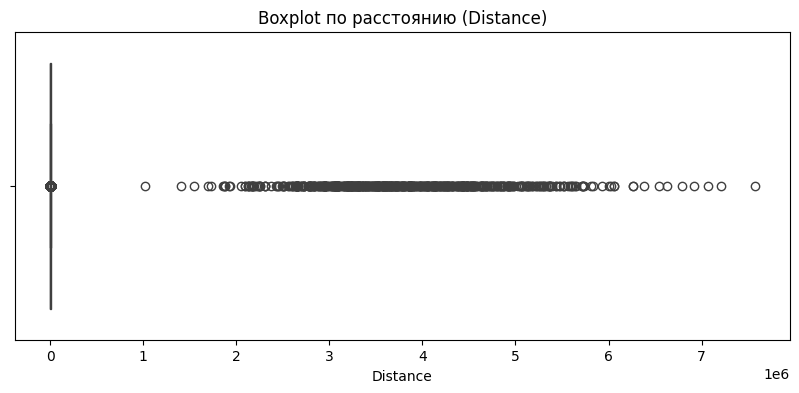

    Start Location  End Location   Distance   Duration
8         западная       озерная        3.0  17.366667
21      лермонтова        дружбы        5.0  29.433333
67          ленина      овражная        5.0  52.216667
70    строительная  строительная        4.0  17.900000
108      заводская     свердлова        4.0  33.466667
128     спортивная       свободы  4416111.0  29.966667
135        полевая    пионерская  6627165.0  49.450000
144      березовая       майская        4.0  37.350000
189        луговая         труда        4.0  42.383333
221   дзержинского     восточная        4.0  23.633333
Количество аномальных строк в Distance: 3514
Количество поездок с дистанцией меньше 100 м: 2923
Количество поездок с дистанцией более 10000 м: 591


In [43]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Distance'])
plt.title("Boxplot по расстоянию (Distance)")
plt.show()

anomalies_distance = df[(df['Distance'] <= 100) | (df['Distance'] > 10000)]
anomalies_count = anomalies_distance.shape[0]
print(anomalies_distance[['Start Location', 'End Location', 'Distance', 'Duration']].head(10))

low_distance_count = df[df['Distance'] < 100].shape[0]
high_distance_count = df[df['Distance'] > 10000].shape[0]

print(f"Количество аномальных строк в Distance: {anomalies_count}")
print(f"Количество поездок с дистанцией меньше 100 м: {low_distance_count}")
print(f"Количество поездок с дистанцией более 10000 м: {high_distance_count}")

Количество выбросов по каждому району:
Start District
центральный        917
юго-восточный      658
северо-западный    594
ленинский          539
октябрьский        479
заречный           338
Name: is_outlier, dtype: int64
Аномальных строк по условию Distance < 100: 2923
Аномальных строк по условию Distance > upper_bound: 607
Выбросы по Distance удалены.


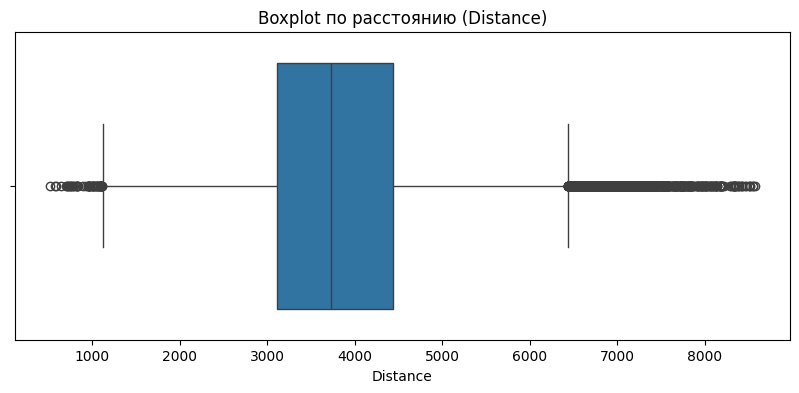

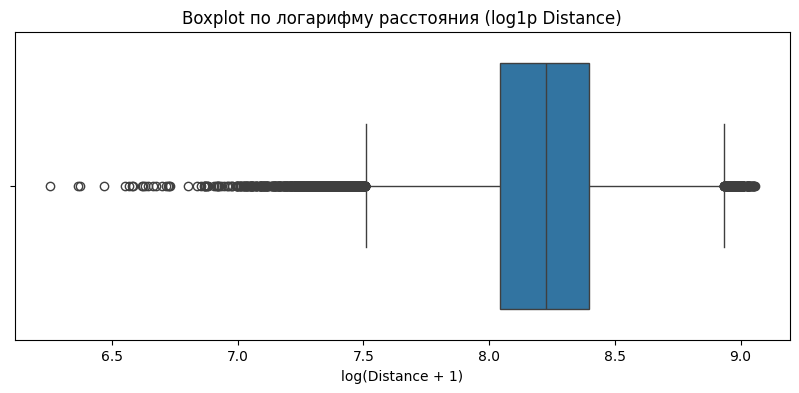

In [44]:
# Квартильные границы
q1 = df['Distance'].quantile(0.25)
q3 = df['Distance'].quantile(0.75)
iqr = q3 - q1

# Границы для определения выбросов
condition = (df['Distance'] < 100) & (df['Duration'] > 8)
upper_bound = q3 + 3 * iqr

df1 = df.copy()
df1['is_outlier'] = (condition) | (df1['Distance'] > upper_bound)
outliers_by_district = df1.groupby('Start District')['is_outlier'].sum()
print("Количество выбросов по каждому району:")
print(outliers_by_district.sort_values(ascending=False))

condition = (df['Distance'] < 100)
condition_large = (df['Distance'] > upper_bound)

print(f"Аномальных строк по условию Distance < 100: {condition.sum()}")
print(f"Аномальных строк по условию Distance > upper_bound: {condition_large.sum()}")

df = df[(df['Distance'] >= 100) & (df['Distance'] <= upper_bound)]

print("Выбросы по Distance удалены.")


plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Distance'])
plt.title("Boxplot по расстоянию (Distance)")
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=np.log1p(df['Distance']))  # log1p = log(1 + x) для работы с нулями
plt.title("Boxplot по логарифму расстояния (log1p Distance)")
plt.xlabel("log(Distance + 1)")
plt.show()


- Удалено аномальных строк по условию Distance < 100: 2923
- Удалено Аномальных строк по условию Distance > upper_bound: 60
#####
Выбросы по Distance удалены.

##### Почему могли возникнуть аномалии и такие выбросы?
##### - GPS плохо работает в центре, поэтому не видно остановку самоката, следовательно время поездки увеличивается, не смотря на стоячее положение
##### - По распределению пропусков видно, что в центре аномалий больше, что также можно приурочить к некорректной работе GPS**

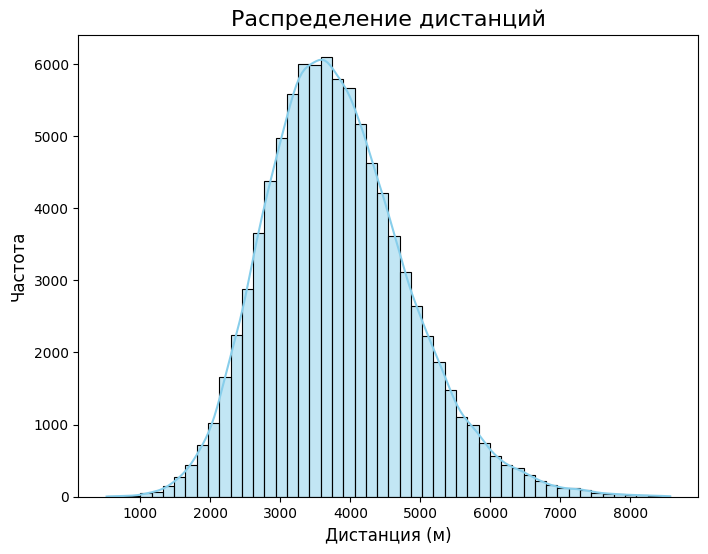

In [47]:
df = df[df['Distance'] <= 10000]
plt.figure(figsize=(8, 6))
sns.histplot(df['Distance'], kde=True, color='skyblue', bins=50)

plt.title('Распределение дистанций', fontsize=16)
plt.xlabel('Дистанция (м)', fontsize=12)
plt.ylabel('Частота', fontsize=12)

plt.show()

In [48]:
missing_end_date = df[df['End Date'].isna()]
print(f"Пропусков в 'End Date': {len(missing_end_date)}")

print(missing_end_date[['Start Date', 'End Date']].head(10))


Пропусков в 'End Date': 0
Empty DataFrame
Columns: [Start Date, End Date]
Index: []


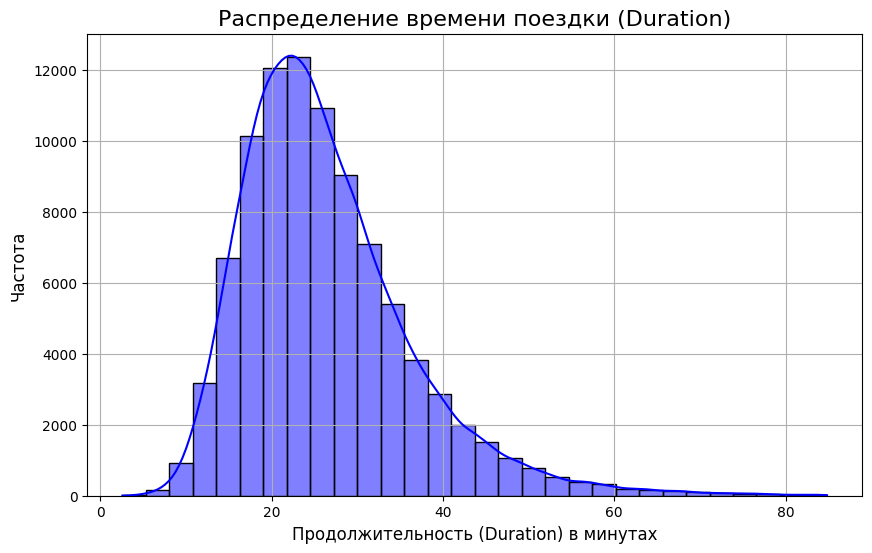

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Построение гистограммы распределения для столбца 'Duration'
plt.figure(figsize=(10, 6))
sns.histplot(df['Duration'], kde=True, bins=30, color='blue')

# Настройки графика
plt.title('Распределение времени поездки (Duration)', fontsize=16)
plt.xlabel('Продолжительность (Duration) в минутах', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.grid(True)

# Показать график
plt.show()

# Нормализация данных в столбцах DataFrame df

**Добавляем в DataFrame df новые признаки (колонки), которые помогают глубже анализировать данные поездок: когда они происходили, как долго длились, с какой скоростью и в какое время суток.**

In [52]:
df['Start Month'] = df['Start Date'].dt.month
df['End Month'] = df['End Date'].dt.month

seasons = {
    12: 'Зима', 1: 'Зима', 2: 'Зима',
    3: 'Весна', 4: 'Весна', 5: 'Весна',
    6: 'Лето', 7: 'Лето', 8: 'Лето',
    9: 'Осень', 10: 'Осень', 11: 'Осень'
}

df['Start Season'] = df['Start Month'].map(seasons)
df['End Season'] = df['End Month'].map(seasons)

df['Time Start'] = df['Start Date'].dt.time
df['Time End'] = df['End Date'].dt.time

df['Duration'] = (df['End Date'] - df['Start Date']).dt.total_seconds() / 60

df['Distance'] = pd.to_numeric(df['Distance'], errors='coerce')
df['Speed (km/h)'] = (df['Distance'] / 1000) / (df['Duration'] / 60)

def time_day(x):
    if 5 <= x <= 12:
        return 'Утро'
    elif 12 < x <= 18:
        return 'День'
    elif 18 < x <= 22:
        return 'Вечер'
    return 'Ночь'

df['Time of Day'] = df['Start Date'].apply(lambda x: time_day(x.hour))
df.loc[:, 'Start Hour'] = df['Start Date'].dt.hour
df.loc[:, 'Day of Week'] = df['Start Date'].dt.day_name()
df.head(10)

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,End Month,Start Season,End Season,Time of Day,Start Hour,Day of Week,Time Start,Time End,Duration,Speed (km/h)
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:01:03,09:24:45,23.700000,10.301266
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:01:07,09:29:32,28.416667,9.533138
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:04:27,09:42:46,38.316667,7.077860
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:06:34,09:38:23,31.816667,7.318806
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:09:27,09:40:07,30.666667,7.882826
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,лесная,юго-восточный,западная,ленинский,4879.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:10:09,09:49:56,39.783333,7.358358
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,пролетарская,центральный,свободы,ленинский,1846.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:15:12,09:26:01,10.816667,10.239753
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,комарова,ленинский,западная,ленинский,3133.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:19:13,09:40:03,20.833333,9.023040
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,свободы,ленинский,чкалова,юго-восточный,5263.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:28:00,10:02:08,34.133333,9.251367
10,100350,2023-04-22 09:37:57,2023-04-22 09:52:42,коммунальная,юго-восточный,строителей,центральный,2731.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:37:57,09:52:42,14.750000,11.109153


**Поиск и удаление дубликатов в DataFrame df, основываясь на дате начала поездки и районе отправления.**

In [179]:
duplicates = df[df.duplicated(subset=['Start Date', 'Start District'], keep=False)]
df = df.drop_duplicates(subset=['Start Date', 'Start District'], keep='first')
df.head(10)

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,...,Time Start,Time End,Duration,Speed (km/h),Weekday,Day Type,Rate per Minute,Trip Cost,weekday,Days
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0,4,...,09:01:03,09:24:45,23.700000,10.301266,5,Выходной,4,124.800000,5,22
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0,4,...,09:01:07,09:29:32,28.416667,9.533138,5,Выходной,4,143.666667,5,22
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0,4,...,09:04:27,09:42:46,38.316667,7.077860,5,Выходной,4,183.266667,5,22
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0,4,...,09:06:34,09:38:23,31.816667,7.318806,5,Выходной,4,157.266667,5,22
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0,4,...,09:09:27,09:40:07,30.666667,7.882826,5,Выходной,4,152.666667,5,22
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,лесная,юго-восточный,западная,ленинский,4879.0,0,4,...,09:10:09,09:49:56,39.783333,7.358358,5,Выходной,4,189.133333,5,22
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,пролетарская,центральный,свободы,ленинский,1846.0,0,4,...,09:15:12,09:26:01,10.816667,10.239753,5,Выходной,4,73.266667,5,22
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,комарова,ленинский,западная,ленинский,3133.0,0,4,...,09:19:13,09:40:03,20.833333,9.023040,5,Выходной,4,113.333333,5,22
8,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,свободы,ленинский,чкалова,юго-восточный,5263.0,0,4,...,09:28:00,10:02:08,34.133333,9.251367,5,Выходной,4,166.533333,5,22
9,100350,2023-04-22 09:37:57,2023-04-22 09:52:42,коммунальная,юго-восточный,строителей,центральный,2731.0,0,4,...,09:37:57,09:52:42,14.750000,11.109153,5,Выходной,4,89.000000,5,22


# Анализ факторов, влияющих на спрос, и визуализирует результаты. Он показывает когда (по сезонам, дням, часам) чаще всего происходят поездки, а также среднюю длительность поездок в зависимости от времени года

Start Season
Весна    26.393389
Лето     26.363113
Name: Duration, dtype: float64
Day of Week
Sunday       17131
Saturday     16981
Friday       13314
Monday       12035
Wednesday    11030
Thursday     10899
Tuesday      10567
Name: count, dtype: int64
Start Hour
0     1102
1      534
2      413
3      178
4      204
5      789
6     2322
7     3314
8     3757
9     3618
10    3504
11    3063
12    3433
13    3949
14    5000
15    5782
16    6693
17    7337
18    7748
19    8203
20    7705
21    5988
22    4565
23    2756
Name: count, dtype: int64


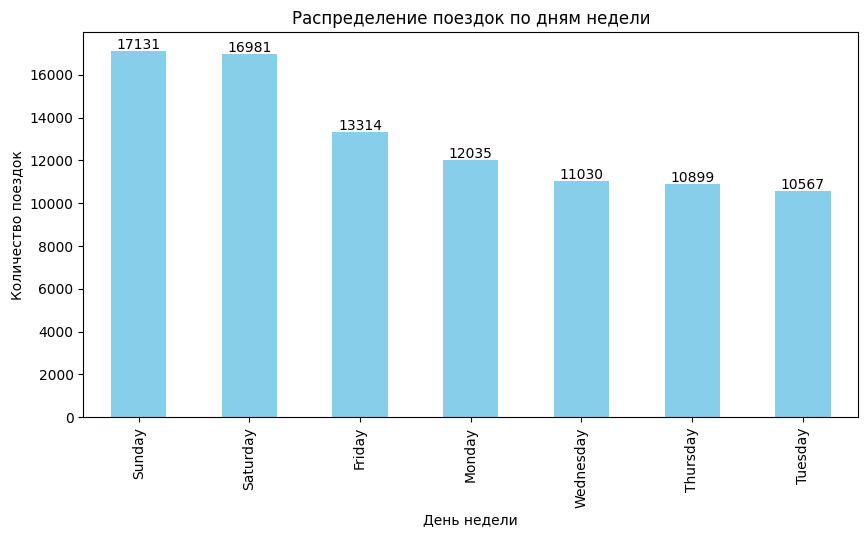

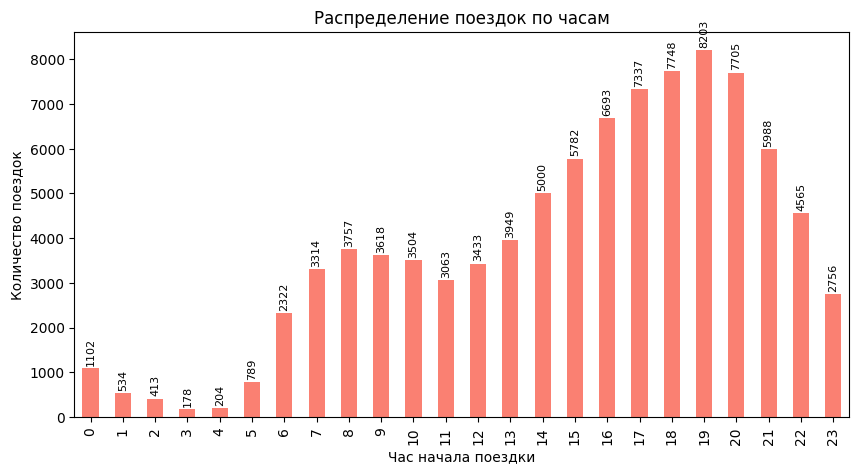

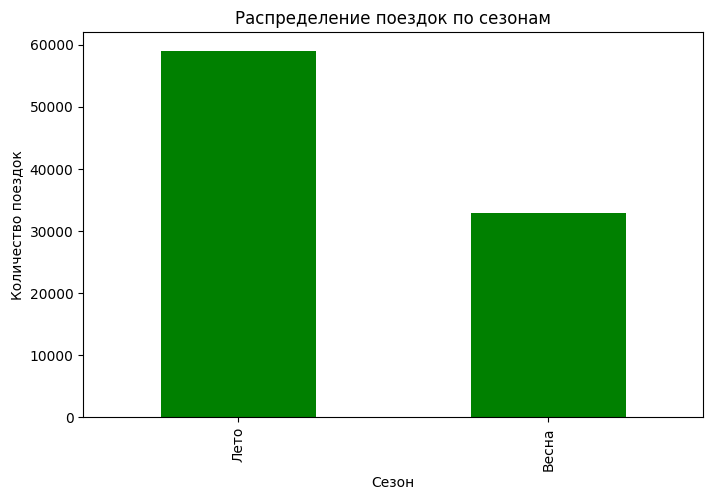

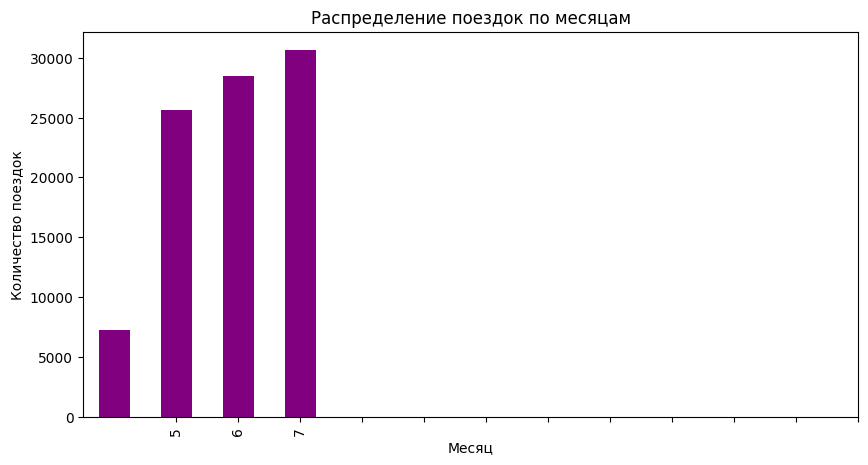

In [56]:
# Анализ факторов, влияющих на спрос
# 1. Средняя длительность поездки по сезонам
season_duration = df.groupby('Start Season')['Duration'].mean()
print(season_duration)

# 2. Количество поездок по дням недели
day_counts = df['Day of Week'].value_counts()
print(day_counts)

# 3. Количество поездок по часам
hour_counts = df['Start Hour'].value_counts().sort_index()
print(hour_counts)

# 4. Количество поездок по сезонам
season_counts = df['Start Season'].value_counts()

# 5. Количество поездок по месяцам
month_counts = df['Start Month'].value_counts().sort_index()

# Визуализация данных с аннотациями
plt.figure(figsize=(10, 5))
day_counts.plot(kind='bar', color='skyblue')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по дням недели')
for i, v in enumerate(day_counts):
    plt.text(i, v + 100, str(v), ha='center', fontsize=10)
plt.show()

plt.figure(figsize=(10, 5))
hour_counts.plot(kind='bar', color='salmon')
plt.xlabel('Час начала поездки')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по часам')
for i, v in enumerate(hour_counts):
    plt.text(i, v + 100, str(v), ha='center', fontsize=8, rotation=90)
plt.show()

plt.figure(figsize=(8, 5))
season_counts.plot(kind='bar', color='green')
plt.xlabel('Сезон')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по сезонам')
plt.show()

plt.figure(figsize=(10, 5))
month_counts.plot(kind='bar', color='purple')
plt.xlabel('Месяц')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по месяцам')
plt.xticks(range(1, 13))
plt.show()

#### ГИПОТЕЗА 1: Нулевая гипотеза: День недели влияет на количество поездок: в выходные поездок больше

Day of Week
Sunday       17131
Saturday     16981
Friday       13314
Monday       12035
Wednesday    11030
Thursday     10899
Tuesday      10567
Name: count, dtype: int64


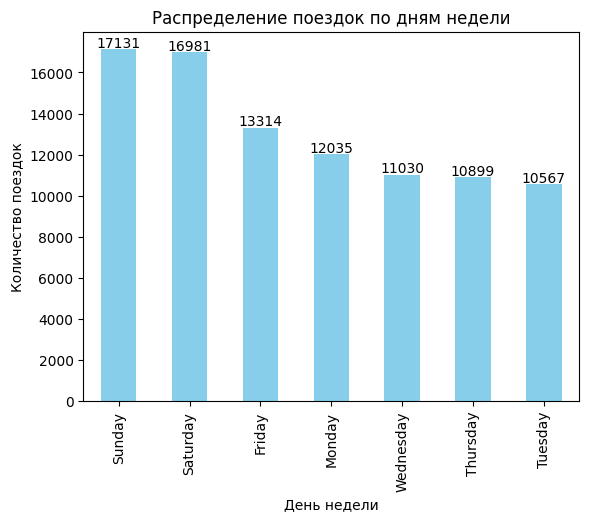

In [58]:
# 2. Количество поездок по дням недели
day_counts = df['Day of Week'].value_counts()
print(day_counts)
day_counts.plot(kind='bar', color='skyblue')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по дням недели')
for i, v in enumerate(day_counts):
    plt.text(i, v + 100, str(v), ha='center', fontsize=10)
plt.show()

**Анализ распределения поездок по районам в будние и выходные дни.**

In [60]:
df['Day of Week'] = df['Start Date'].dt.weekday
df['Weekday'] = df['Start Date'].dt.weekday  # создаём колонку с номером дня недели
df['Day Type'] = df['Weekday'].apply(lambda x: 'Будний день' if x < 5 else 'Выходной')

district_day_type_distribution = (
    df.groupby(['Day Type', 'Start District'])
       .size()
       .reset_index(name='Количество поездок')
)

day_type_order = ['Будний день', 'Выходной']
district_day_type_distribution['Day Type'] = pd.Categorical(
    district_day_type_distribution['Day Type'],
    categories=day_type_order,
    ordered=True
)

district_day_type_distribution = (
    district_day_type_distribution
    .sort_values(by=['Day Type', 'Количество поездок'], ascending=[True, False])
    .reset_index(drop=True)
)
print(district_day_type_distribution)

       Day Type   Start District  Количество поездок
0   Будний день      центральный               15521
1   Будний день    юго-восточный               10914
2   Будний день        ленинский                9150
3   Будний день  северо-западный                9078
4   Будний день      октябрьский                7785
5   Будний день         заречный                5397
6      Выходной      центральный                8120
7      Выходной    юго-восточный                6555
8      Выходной        ленинский                5579
9      Выходной  северо-западный                5546
10     Выходной      октябрьский                4883
11     Выходной         заречный                3429


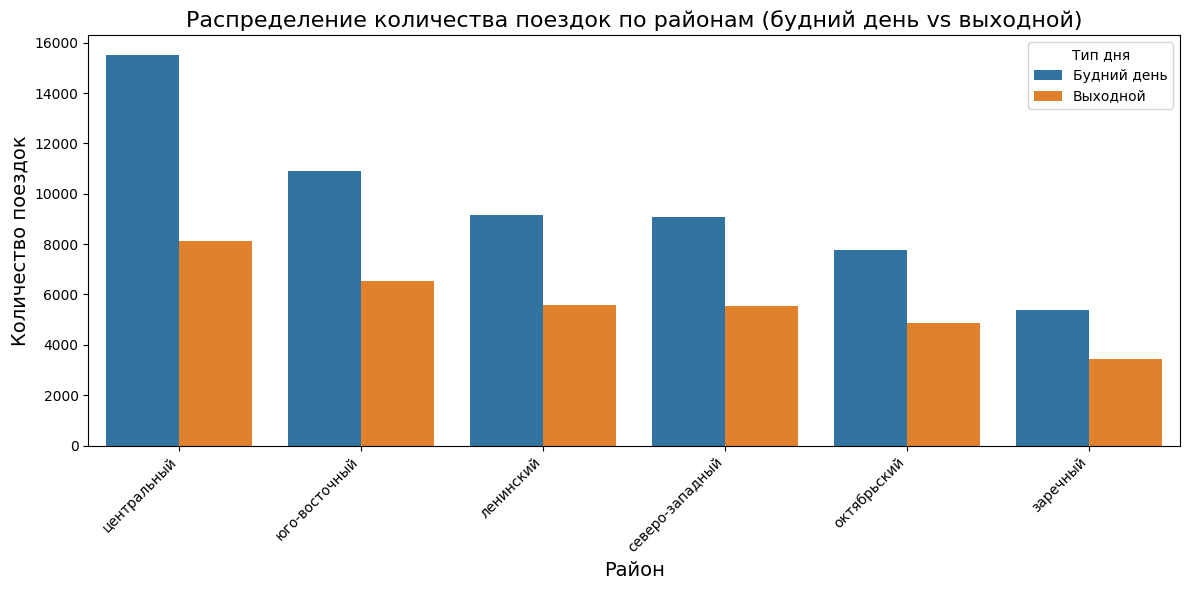

In [61]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Start District', y='Количество поездок', hue='Day Type', data=district_day_type_distribution)

plt.title('Распределение количества поездок по районам (будний день vs выходной)', fontsize=16)
plt.xlabel('Район', fontsize=14)
plt.ylabel('Количество поездок', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Тип дня')

plt.tight_layout()
plt.show()

#### Итог: Нулевая гипотеза подтверждена
#### День недели кардинально влияет на распределение поездок, в выходные дни и пятницу поездок наблюдается значительно больше

#### ГИПОТЕЗА 2: Нулевая гипотеза: В будние дни средняя скорость выше
#### Построение графика распределения поездок по дням недели со скоростью по каждому дню

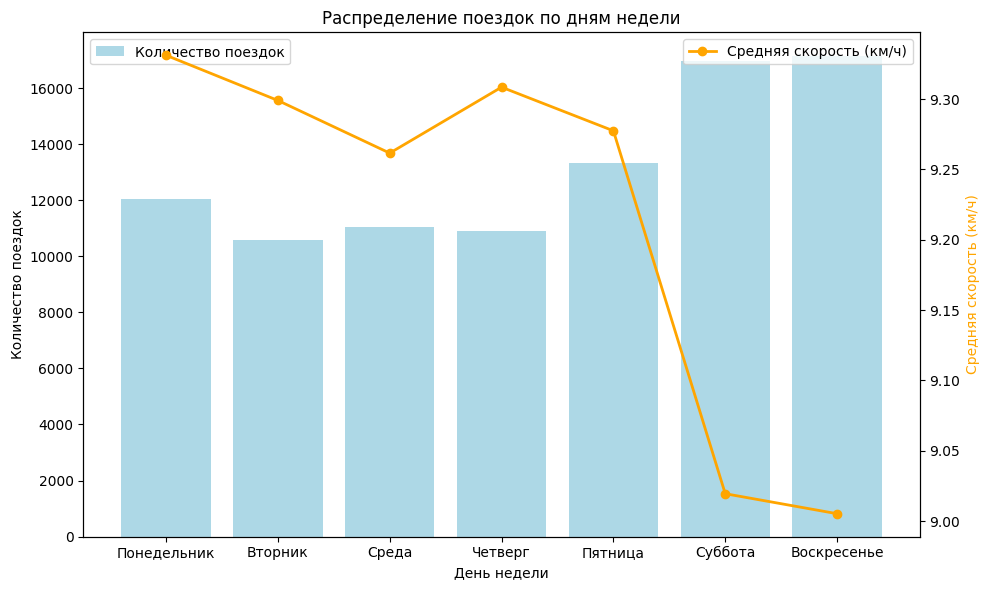

In [64]:
speed_by_weekday = df.groupby('Weekday')['Speed (km/h)'].agg(['mean', 'count']).reset_index()

# Получаем имена дней недели для отображения на графике
weekday_names = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
speed_by_weekday['Weekday Name'] = speed_by_weekday['Weekday'].map(lambda x: weekday_names[x])

# Сортируем по дню недели для корректного отображения
speed_by_weekday = speed_by_weekday.sort_values(by='Weekday')

fig, ax1 = plt.subplots(figsize=(10, 6))

# График количества поездок
ax1.bar(speed_by_weekday['Weekday Name'], speed_by_weekday['count'], color='lightblue', label='Количество поездок')
ax1.set_xlabel('День недели')
ax1.set_ylabel('Количество поездок')
ax1.set_title('Распределение поездок по дням недели')

# Добавим второй график для средней скорости
ax2 = ax1.twinx()
ax2.plot(speed_by_weekday['Weekday Name'], speed_by_weekday['mean'], color='orange', marker='o', label='Средняя скорость (км/ч)', linewidth=2)
ax2.set_ylabel('Средняя скорость (км/ч)', color='orange')

# Показать легенду
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Показать график
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Итог: Нулевая гипотеза подтверждается.
#### В будние дни средняя скорость значительно больше. Предположение: В субботу и воскресенье пользователи предпочитают кататься по паркам, где есть ограничение по скорости + некуда торопиться, поездка превращается в прогулочную

**Строим гистограмму распределения дистанций поездок**

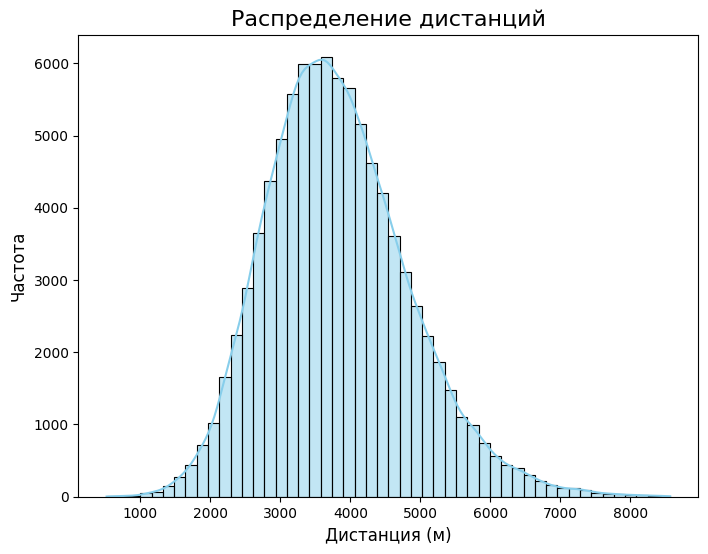

In [67]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Distance'], kde=True, color='skyblue', bins=50)

# Добавим подписи и заголовок
plt.title('Распределение дистанций', fontsize=16)
plt.xlabel('Дистанция (м)', fontsize=12)
plt.ylabel('Частота', fontsize=12)

# Показать график
plt.show()

# Рассчитываем стоимость каждой поездки на основе времени суток и дня недели, применяя динамическую тарифную сетку.

In [69]:
# def get_rate(weekday, hour):
#     if weekday < 5:  # Пн–Пт
#         if 1 <= hour < 6:
#             return 3
#         elif 6 <= hour < 10:
#             return 4
#         elif 10 <= hour < 16:
#             return 5
#         elif 16 <= hour < 22:
#             return 6
#         else:  # 22:00 – 01:00 (hour 22, 23, 0)
#             return 5
#     else:  # Сб–Вс
#         if 1 <= hour < 6:
#             return 3
#         elif 6 <= hour < 10:
#             return 4
#         elif 10 <= hour < 16:
#             return 6
#         elif 16 <= hour < 22:
#             return 7
#         else:  # 22:00 – 01:00 (hour 22, 23, 0)
#             return 6


# df['Weekday'] = df['Start Date'].dt.weekday
# df['Start Hour'] = df['Start Date'].dt.hour

# df['Rate per Minute'] = df.apply(lambda row: get_rate(row['Weekday'], row['Start Hour']), axis=1)

# df['Trip Cost'] = df['Duration'] * df['Rate per Minute']
# df.head(10)


In [70]:
# Стоимость старта
start_cost = 30

# Функция для расчета стоимости
def get_rate(weekday, hour):
    if weekday < 5:  # Пн–Пт
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 5
        elif 16 <= hour < 22:
            return 6
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 5
    else:  # Сб–Вс
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 6
        elif 16 <= hour < 22:
            return 7
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 6

# Функция для расчета итоговой стоимости поездки
def calculate_trip_cost(row):
    weekday = row['Weekday']
    start_hour = row['Start Hour']
    duration = row['Duration']  # длительность поездки в минутах
    promo = row['Promo']
    
    # Получаем стоимость минуты по времени и дню недели
    rate = get_rate(weekday, start_hour)
    
    # Если акция, бесплатный старт, но учитываем длительность и стоимость минуты
    if promo == 1 and (weekday == 0 and 6 <= start_hour < 10):  # Понедельник, с 6:00 до 10:00
        return duration * rate  # бесплатный старт, считаем только длительность * стоимость минуты
    else:
        # Если без промо или не понедельник с акцией
        return start_cost + (duration * rate)
df['Rate per Minute'] = df.apply(lambda row: get_rate(row['Weekday'], row['Start Hour']), axis=1)
# Применяем функцию к DataFrame
df['Trip Cost'] = df.apply(calculate_trip_cost, axis=1)
df.head(10)

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,...,Start Hour,Day of Week,Time Start,Time End,Duration,Speed (km/h),Weekday,Day Type,Rate per Minute,Trip Cost
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0,4,...,9,5,09:01:03,09:24:45,23.700000,10.301266,5,Выходной,4,124.800000
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0,4,...,9,5,09:01:07,09:29:32,28.416667,9.533138,5,Выходной,4,143.666667
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0,4,...,9,5,09:04:27,09:42:46,38.316667,7.077860,5,Выходной,4,183.266667
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0,4,...,9,5,09:06:34,09:38:23,31.816667,7.318806,5,Выходной,4,157.266667
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0,4,...,9,5,09:09:27,09:40:07,30.666667,7.882826,5,Выходной,4,152.666667
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,лесная,юго-восточный,западная,ленинский,4879.0,0,4,...,9,5,09:10:09,09:49:56,39.783333,7.358358,5,Выходной,4,189.133333
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,пролетарская,центральный,свободы,ленинский,1846.0,0,4,...,9,5,09:15:12,09:26:01,10.816667,10.239753,5,Выходной,4,73.266667
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,комарова,ленинский,западная,ленинский,3133.0,0,4,...,9,5,09:19:13,09:40:03,20.833333,9.023040,5,Выходной,4,113.333333
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,свободы,ленинский,чкалова,юго-восточный,5263.0,0,4,...,9,5,09:28:00,10:02:08,34.133333,9.251367,5,Выходной,4,166.533333
10,100350,2023-04-22 09:37:57,2023-04-22 09:52:42,коммунальная,юго-восточный,строителей,центральный,2731.0,0,4,...,9,5,09:37:57,09:52:42,14.750000,11.109153,5,Выходной,4,89.000000


**Столбчатая диаграмму (bar plot), показывающую распределение поездок по времени суток (Утро, День, Вечер, Ночь)**

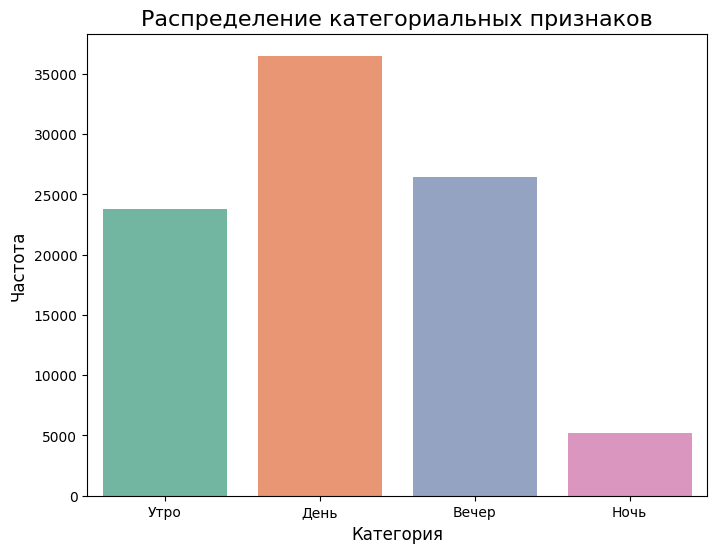

In [72]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Time of Day', data=df, palette='Set2')

plt.title('Распределение категориальных признаков', fontsize=16)
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Частота', fontsize=12)

plt.show()

**Два анализа: один — визуализирует распределение стоимости поездки по районам, а второй — рассчитывает среднюю продолжительность поездки по районам.**

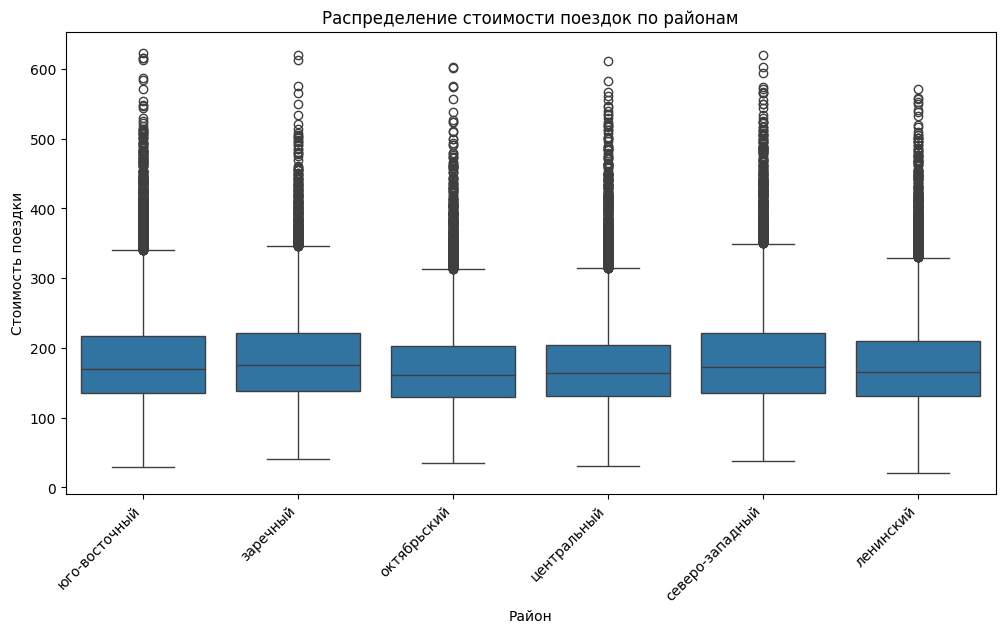

Start District
заречный           27.755395
северо-западный    27.680513
юго-восточный      27.184948
ленинский          26.141154
октябрьский        25.246027
центральный        25.200127
Name: Duration, dtype: float64


In [74]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Start District', y='Trip Cost', data=df)

plt.xticks(rotation=45, ha='right')
plt.xlabel('Район')
plt.ylabel('Стоимость поездки')
plt.title('Распределение стоимости поездок по районам')

plt.show()

average_duration_by_district = df.groupby('Start District')['Duration'].mean().sort_values(ascending=False)
print(average_duration_by_district)

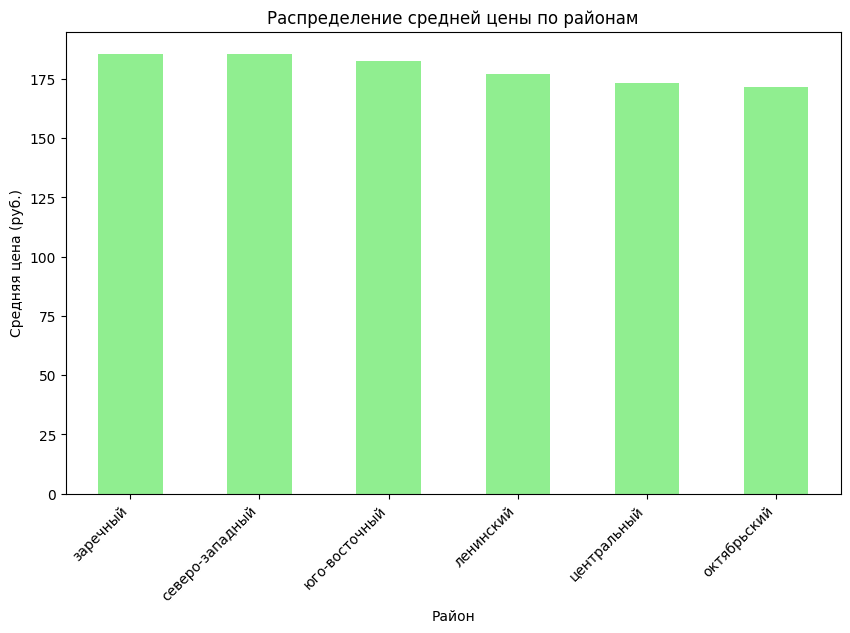

In [75]:
district_price = df.groupby('Start District')['Trip Cost'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
district_price.plot(kind='bar', color='lightgreen')
plt.xlabel('Район')
plt.ylabel('Средняя цена (руб.)')
plt.title('Распределение средней цены по районам')
plt.xticks(rotation=45, ha='right')
plt.show()

График для отображения средней продолжительности поездки по различным районам, чтобы наглядно сравнить, где поездки в среднем длительнее, а где короче.

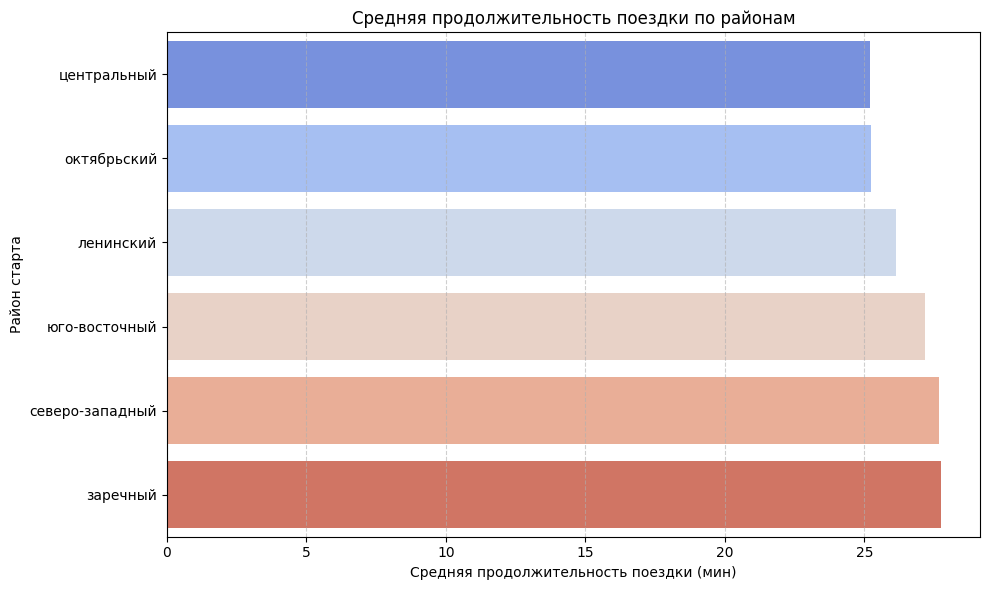

In [77]:
district_durations = df.groupby("Start District")["Duration"].mean().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=district_durations.values, y=district_durations.index, palette="coolwarm")
plt.xlabel("Средняя продолжительность поездки (мин)")
plt.ylabel("Район старта")
plt.title("Средняя продолжительность поездки по районам")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

** Тепловая карта для визуализации распределения количества поездок по часам дня и районам старта.
- Группировка данных по району старта и часу:
- Сортировка районов по убыванию количества поездок:
- Создание сводной таблицы (pivot table):
- Сортировка таблицы по убыванию количества поездок в районах:
- Построение тепловой карты (Heatmap):
- Настройки графика: **

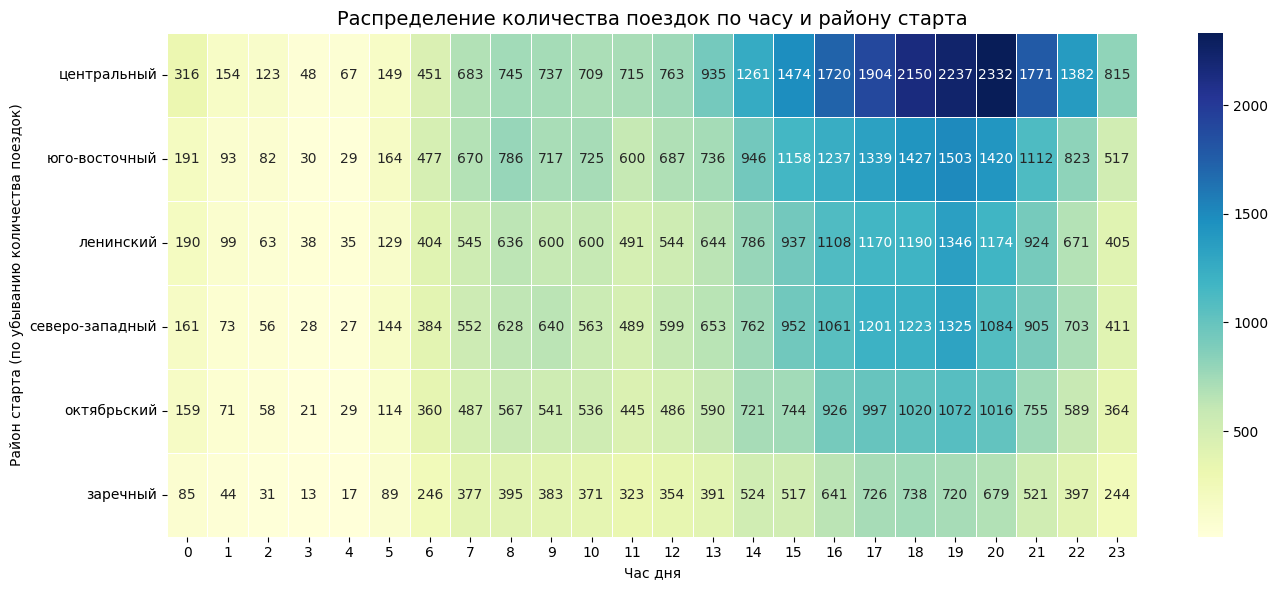

In [79]:
grouped = df.groupby(['Start District', 'Start Hour']).size().reset_index(name='Trip Count')
district_order = df['Start District'].value_counts().index.tolist()
pivot_table = grouped.pivot(index='Start District', columns='Start Hour', values='Trip Count').fillna(0)

pivot_table = pivot_table.reindex(district_order)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_table, cmap="YlGnBu", annot=True, fmt=".0f", linewidths=.5)
plt.title("Распределение количества поездок по часу и району старта", fontsize=14)
plt.xlabel("Час дня")
plt.ylabel("Район старта (по убыванию количества поездок)")
plt.tight_layout()
plt.show()

In [80]:
df['Day Type'] = df['Weekday'].apply(lambda x: 'Будний день' if x < 5 else 'Выходной')

district_day_type_distribution = (
    df.groupby(['Day Type', 'Start District'])
       .size()
       .reset_index(name='Количество поездок')
)

day_type_order = ['Будний день', 'Выходной']
district_day_type_distribution['Day Type'] = pd.Categorical(
    district_day_type_distribution['Day Type'],
    categories=day_type_order,
    ordered=True
)

district_day_type_distribution = (
    district_day_type_distribution
    .sort_values(by=['Day Type', 'Количество поездок'], ascending=[True, False])
    .reset_index(drop=True)
)

print(district_day_type_distribution)

       Day Type   Start District  Количество поездок
0   Будний день      центральный               15521
1   Будний день    юго-восточный               10914
2   Будний день        ленинский                9150
3   Будний день  северо-западный                9078
4   Будний день      октябрьский                7785
5   Будний день         заречный                5397
6      Выходной      центральный                8120
7      Выходной    юго-восточный                6555
8      Выходной        ленинский                5579
9      Выходной  северо-западный                5546
10     Выходной      октябрьский                4883
11     Выходной         заречный                3429


**Два анализа: один — визуализирует распределение стоимости поездки по районам, а второй — рассчитывает среднюю продолжительность поездки по районам.**

**Выведем несколько значений.
Среднее значение стоимости поездки:
Максимальное значение стоимости поездки:
Медиану стоимости поездки:**


In [83]:
print(df['Trip Cost'].mean())
print(df['Trip Cost'].max())
print(df['Trip Cost'].median())

178.52653957828116
623.3666666666667
167.10000000000002


График для отображения средней продолжительности поездки по различным районам, чтобы наглядно сравнить, где поездки в среднем длительнее, а где короче.

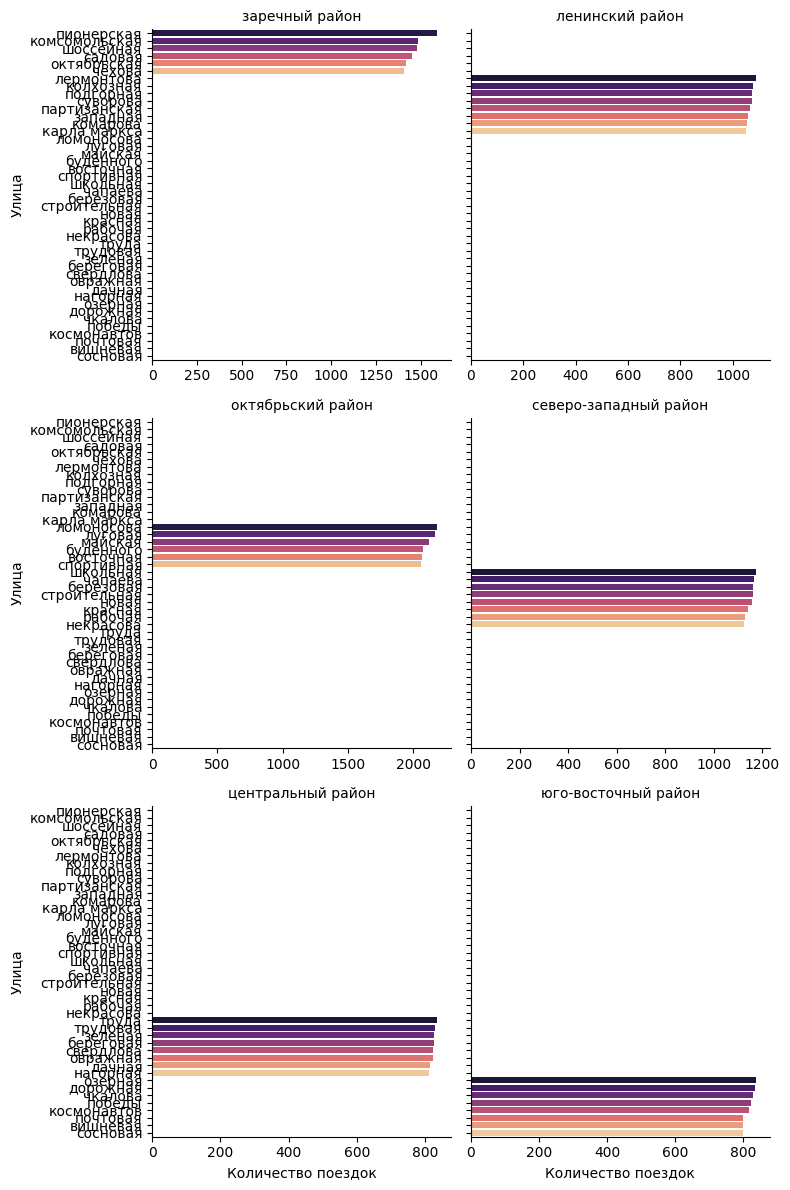

In [85]:
street_distribution = df.groupby(['Start District', 'Start Location']).size().reset_index(name='Поездок')

street_distribution = street_distribution.sort_values(['Start District', 'Поездок'], ascending=[True, False])
g = sns.FacetGrid(
    street_distribution.groupby('Start District').head(8),  # Топ улиц на район
    col='Start District', col_wrap=2, height=4, sharex=False
)
g.map_dataframe(sns.barplot, x='Поездок', y='Start Location', palette='magma')
g.set_titles(col_template="{col_name} район")
g.set_axis_labels("Количество поездок", "Улица")
plt.tight_layout()
plt.show()

**Гистограммы (barplot) для визуализации распределения количества поездок по улицам в разных районах, используя библиотеку Seaborn и FacetGrid для создания нескольких подграфиков (facet plots).**

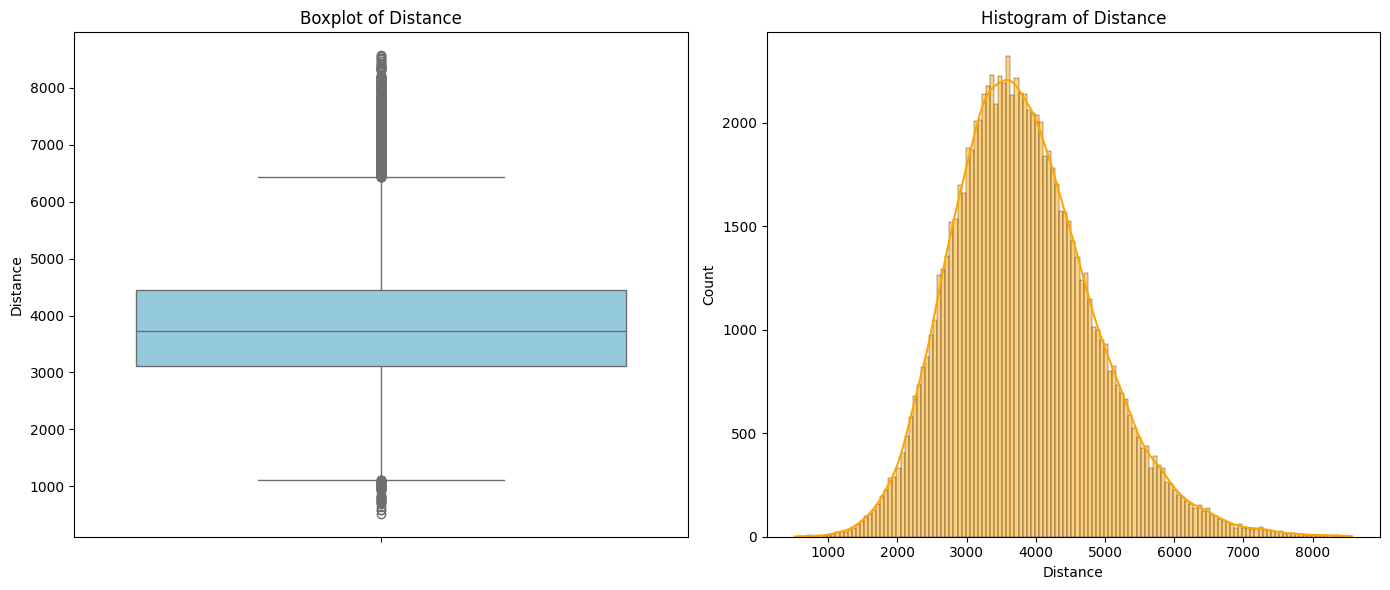

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot (вертикальный)
sns.boxplot(y=df['Distance'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot of Distance')

# Histplot
sns.histplot(df['Distance'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Histogram of Distance')

plt.tight_layout()
plt.show()

# Предобработка погоды

In [89]:
w = w.iloc[1:]

In [90]:
w['Precipitation Total'] = w['Precipitation Total'].fillna(method='ffill')
w['Wind Speed'] = w['Wind Speed'].fillna(method='ffill')
w['Cloud Cover Total'] = w['Cloud Cover Total'].fillna(method='ffill')
w['Sunshine Duration'] = w['Sunshine Duration'].fillna(method='ffill')
w['Datetime'] = w['Datetime'].dropna()

In [91]:
def time_of_the_year(x):
    d = {
        1: 'Winter',
        2: 'Winter',
        3: 'Spring',
        4: 'Spring',
        5: 'Spring',
        6: 'Summer',
        7: 'Summer',
        8: 'Summer',
        9: 'Autumn',
        10: 'Autumn',
        11: 'Autumn',
        12: 'Winter',
    }
    return d[x]
dw = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

w['Datetime'] = pd.to_datetime(w['Datetime'])
w['Time of the year'] = w['Datetime'].apply(lambda x: time_of_the_year(x.month))

In [92]:
test_df = w[w['Temperature'].isna()]  # Строки, где Temperature == NaN
train_df = w[w['Temperature'].notna()]  # Строки, где Temperature не NaN

In [93]:
train_df['Precipitation Total'] = train_df['Precipitation Total'].astype('float')
train_df = train_df[train_df['Precipitation Total'] < 3]

In [94]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [95]:
df_ohe = pd.get_dummies(train_df, columns=['Time of the year'], prefix='Category')

In [96]:
df_ohe['Category_Summer'] = df_ohe['Category_Summer'].astype('float')
df_ohe['Category_Spring'] = df_ohe['Category_Spring'].astype('float')

In [97]:
df_ohe = df_ohe.drop(columns=['Datetime'])

In [98]:
df_ohe.isna().sum()

Temperature            0
Precipitation Total    0
Wind Gust              0
Wind Speed             0
Cloud Cover Total      0
Sunshine Duration      0
Category_Spring        0
Category_Summer        0
dtype: int64

In [99]:
X = df_ohe[['Precipitation Total', 'Wind Gust', 'Wind Speed', 'Cloud Cover Total', 'Sunshine Duration', 'Category_Spring', 'Category_Summer']]  # Признаки (вектора)
y = df_ohe['Temperature']  # Целевой признак (то, что нужно предсказать)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [100]:
# from catboost import CatBoostRegressor
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error

# model = CatBoostRegressor(iterations=10000,  # Максимальное количество итераций
#                           learning_rate=0.1,  # Коэффициент обучения
#                           depth=6,  # Глубина деревьев
#                           cat_features=[],  # Список категориальных признаков (если есть)
#                           verbose=200,  # Печать прогресса
#                           early_stopping_rounds=50)  # Останавливаем обучение, если ошибка не улучшается в течение 50 раундов

# # Обучение модели с валидацией на валидационном наборе
# model.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

# # Прогнозирование
# y_pred = model.predict(X_test)

# # Оценка модели
# mse = mean_squared_error(y_test, y_pred)
# print(f"Среднеквадратичная ошибка (MSE) на тестовых данных: {mse}")

In [101]:
# df_ohe1 = pd.get_dummies(test_df, columns=['Time of the year'], prefix='Category')
# df_ohe1['Category_Summer'] = df_ohe1['Category_Summer'].astype('float')
# df_ohe1['Category_Spring'] = df_ohe1['Category_Spring'].astype('float')
# y_pred1 = model.predict(df_ohe1[['Precipitation Total', 'Wind Gust', 'Wind Speed', 'Cloud Cover Total', 'Sunshine Duration', 'Category_Spring', 'Category_Summer']])
# test_df['Temperature'] = y_pred1

In [102]:
test_df

,Datetime,Temperature,Precipitation Total,Wind Gust,Wind Speed,Cloud Cover Total,Sunshine Duration,Time of the year
363,2023-04-16 02:00:00,NaN,0.3,13.32,3.671294,100,0,Spring
364,2023-04-16 03:00:00,NaN,0.4,13.32,4.452954,98,0,Spring
365,2023-04-16 04:00:00,NaN,0.4,13.32,4.802999,100,0,Spring
366,2023-04-16 05:00:00,NaN,0.3,13.679999,4.379589,100,0,Spring
367,2023-04-16 06:00:00,NaN,0.2,14.4,5.0528407,100,0,Spring
368,2023-04-16 07:00:00,NaN,0.3,15.4800005,6.379216,100,0,Spring
369,2023-04-16 08:00:00,NaN,0.2,19.08,9.957108,100,0,Spring
370,2023-04-16 09:00:00,NaN,0.2,24.48,10.383987,100,0,Spring
371,2023-04-16 10:00:00,NaN,0.2,24.48,7.7043357,100,0,Spring
372,2023-04-16 11:00:00,NaN,0.3,24.84,8.534353,91,4.8484864,Spring


In [103]:
test_df['Datetime'] = test_df['Datetime'].apply(lambda x: pd.to_datetime(x))
train_df['Datetime'] = train_df['Datetime'].apply(lambda x: pd.to_datetime(x))

In [104]:
w1 = pd.concat([train_df, test_df])  # Можно выбрать тип слияния: 'inner', 'outer', 'left', 'right'

In [105]:
# from IPython.display import clear_output


# def find_nearest_date(date1, df2):
#     diff1 = abs(df2['Datetime'] - date1).idxmin()
#     clear_output(wait=True)
#     print(date1)
#     return df2.loc[diff1]

# # Создаем новый DataFrame для хранения результата
# merged_rows = []

# # Для каждой строки в df1 находим ближайшую дату в df2
# for _, row in df.iterrows():
#     nearest_row = find_nearest_date(row['Start Date'], w1)
#     # Объединяем строки по найденной ближайшей дате
#     merged_row = pd.concat([row, nearest_row], axis=0)
#     merged_rows.append(merged_row)

# # Преобразуем список строк в DataFrame
# df = pd.DataFrame(merged_rows)
# df

In [106]:
df = df.reset_index(drop=True)

In [107]:
df['weekday'] = df['Start Date'].dt.weekday

In [108]:
df['Days'] = df['Start Date'].apply(lambda x: x.day)

# 1.Итоговая стоимость

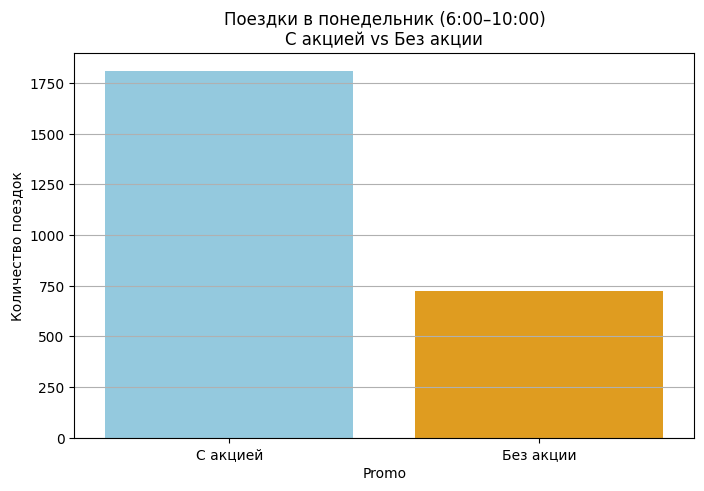

In [207]:

monday_trips = df[(df['Day of Week'] == 0) & (df['Hour'] >= 6) & (df['Hour'] < 10)]
promo_counts = monday_trips['Promo'].value_counts().rename({0: 'Без акции', 1: 'С акцией'})

plt.figure(figsize=(8, 5))
sns.barplot(x=promo_counts.index, y=promo_counts.values, palette=['skyblue', 'orange'])
plt.title('Поездки в понедельник (6:00–10:00)\nС акцией vs Без акции')
plt.ylabel('Количество поездок')
plt.grid(axis='y')
plt.show()

##### Столбец с использованием акции значительно выше -> акция стимулирует спрос

#### Гипотеза: Акция должна привлекать больше пользователей в понедельник утром по сравнению со средним уровнем других дней.

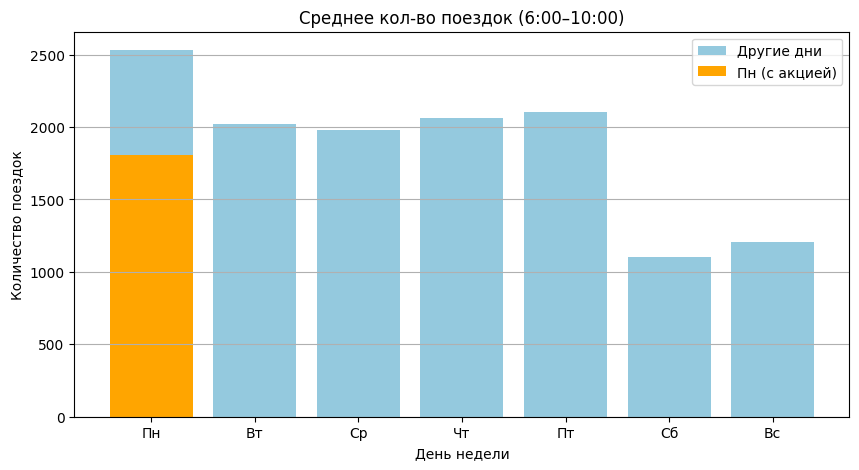

In [215]:
daily_avg = df_6_10.groupby('Day of Week').size()
daily_avg.index = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

monday_promo_avg = len(monday_trips[monday_trips['Promo'] == 1])

plt.figure(figsize=(10, 5))
sns.barplot(x=daily_avg.index, y=daily_avg.values, color='skyblue', label='Другие дни')
plt.bar(x=0, height=monday_promo_avg, color='orange', label='Пн (с акцией)')
plt.title('Среднее кол-во поездок (6:00–10:00)')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.legend()
plt.grid(axis='y')
plt.show()

##### Даже с акцией поездки в понедельник уступают другим дням по количеству.
-  Возможно, пользователи редко применяют промокод или акция недостаточно привлекательн##### Почему общий столбец понедельника выше?
- Без акции (Promo=0) спрос в понедельник и так высок (голубая часть)
- Понедельник — популярный день по естественным причинам (например, поездки на работу после выходных)ных).

Акция «Бесплатный старт» в понедельник утром незначительно увеличивает спрос: лишь 15% поездок используют промокод. Однако общий спрос в понедельник высок за счет естественных причин. Рекомендуется либо усилить акцию (например, расширить скидку), либо отменить ее и перенести на менее популярные дни

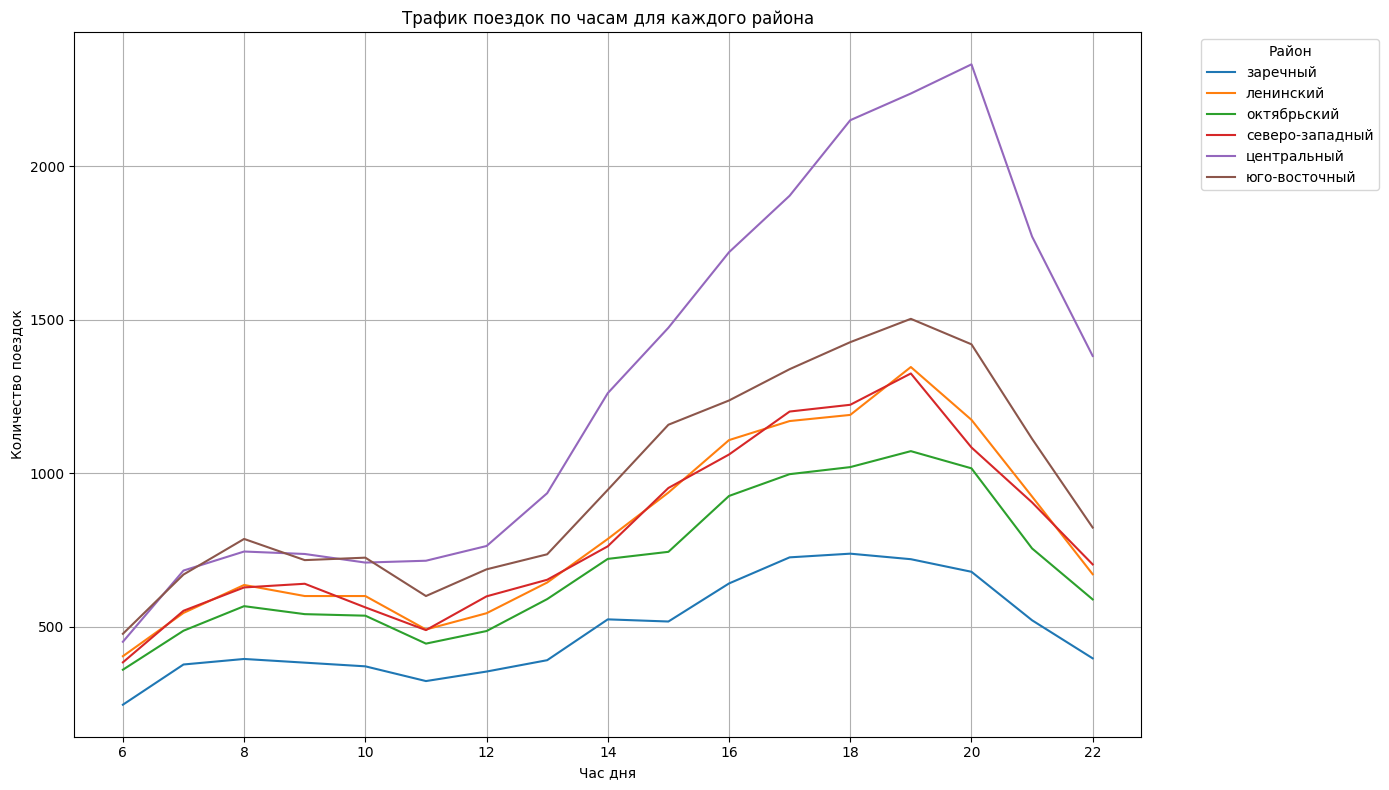

In [265]:
df_filtered = df[(df['Start Hour'] >= 6) & (df['Start Hour'] <= 22)]

traffic_by_district = df_filtered.groupby(['Start District', 'Start Hour']).size().unstack(level=0)

plt.figure(figsize=(14, 8))
sns.lineplot(data=traffic_by_district, dashes=False)
plt.title('Трафик поездок по часам для каждого района')
plt.xlabel('Час дня')
plt.ylabel('Количество поездок')
plt.legend(title='Район', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Гипотеза: Акция может по-разному влиять на спрос в зависимости от района (например, в офисных районах эффект сильнее)

In [256]:
district_promo_ratios = []
top_districts = df_6_10['Start District'].value_counts().head(8).index

for district in top_districts:
    district_data = df_6_10[df_6_10['Start District'] == district]
    promo_ratio = district_data[district_data['Day of Week'] == 0]['Promo'].mean() * 100  # Доля поездок с акцией
    
    district_promo_ratios.append((district, promo_ratio))

district_promo_df = pd.DataFrame(district_promo_ratios, columns=['District', 'Promo Ratio'])

district_promo_df = district_promo_df.sort_values(by='Promo Ratio', ascending=False)
for index, row in district_promo_df.iterrows():
    print(f"{row['District']}: {row['Promo Ratio']:.1f}% поездок в понедельник использовали акцию")


ленинский: 74.8% поездок в понедельник использовали акцию
центральный: 73.8% поездок в понедельник использовали акцию
северо-западный: 71.8% поездок в понедельник использовали акцию
заречный: 69.8% поездок в понедельник использовали акцию
октябрьский: 69.3% поездок в понедельник использовали акцию
юго-восточный: 68.9% поездок в понедельник использовали акцию


В центральном и ленинском районах люди чаще пользуются акциями возможно в связи с их расположением. Как выяснилось ранее, в Центральном

#### Есть ли статистически значимая разница в количестве поездок:
- Между понедельниками с акцией и без акции.
- Между понедельниками с акцией и другими днями.

In [268]:
from scipy.stats import ttest_ind

# Поездки в понедельник с акцией vs без акции
t_stat, p_value = ttest_ind(
    monday_trips[monday_trips['Promo'] == 1]['Duration'],
    monday_trips[monday_trips['Promo'] == 0]['Duration']
)
print(f'P-значение (Пн с акцией vs без): {p_value:.3f}')

# Поездки в понедельник с акцией vs другие дни
t_stat, p_value = ttest_ind(
    monday_trips[monday_trips['Promo'] == 1]['Duration'],
    df_6_10[df_6_10['Day of Week'] != 0]['Duration']
)
print(f'P-значение (Пн с акцией vs другие дни): {p_value:.3f}')

P-значение (Пн с акцией vs без): 0.682
P-значение (Пн с акцией vs другие дни): 0.079


1. Сравнение понедельников с акцией и без акции:
P-значение = 0.682
Это означает, что:- 

Нет статистически значимой разницы в продолжительности поездок между понедельниками с акцией и без аци- и.

Акция не влияет на то, как долго пользователи ездят на самокатах в понедельник.

2. Сравнение понедельников с акцией и других дней:
P-значение = 0.079
Это указы- вает на:

Пограничную статистическузо- к к нему).

Возможно, есть слабая тенденция к отличию продолжительности поездок в понедельник с акцией от других дней, но доказательст недостаточно.

<Figure size 1000x500 with 0 Axes>

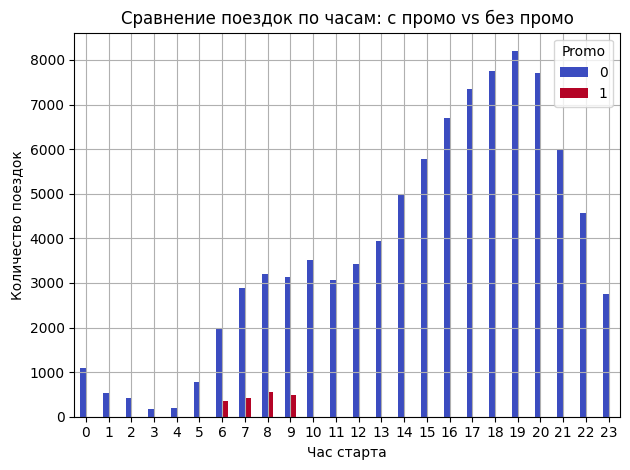

In [225]:
heatmap_data = df.groupby(['Start Hour', 'Promo'])['Id'].count().unstack()

plt.figure(figsize=(10, 5))
heatmap_data.plot(kind='bar', stacked=False, colormap='coolwarm')
plt.title('Сравнение поездок по часам: с промо vs без промо')
plt.xlabel('Час старта')
plt.ylabel('Количество поездок')
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [111]:
# 1. Промо и контрольные периоды
promo_period = (
    (df['Promo'] == 1) &
    (df['Weekday'] == 0) & 
    (df['Start Hour'].between(6, 10))
)

control_period = (
    (df['Promo'] == 0) &
    (df['Start Hour'].between(6, 10)) &
    (df['Weekday'].isin([0, 1, 2, 3, 4, 5, 6]))
)

df_promo = df[promo_period]
df_control = df[control_period]

In [112]:
# 2. Количество поездок
promo_rides = df_promo.shape[0]
avg_control_rides = df_control.groupby('Weekday')['Id'].count().mean()

print(f"Поездки в промо-период (Пн 6:00–10:00): {promo_rides}")
print(f"Среднее число поездок без промо (в другие дни 6:00–10:00): {avg_control_rides:.1f}")

Поездки в промо-период (Пн 6:00–10:00): 1809
Среднее число поездок без промо (в другие дни 6:00–10:00): 2100.9


In [113]:
avg_cost_promo = df_promo['Trip Cost'].mean()
avg_cost_nonpromo = df_control['Trip Cost'].mean()

print(f"Средняя выручка за поездку с промо: {avg_cost_promo:.2f} руб.")
print(f"Средняя выручка за поездку без промо: {avg_cost_nonpromo:.2f} руб.")

Средняя выручка за поездку с промо: 98.88 руб.
Средняя выручка за поездку без промо: 138.99 руб.


Среднее число поездок в Пн (акция): 3020.0
Среднее число поездок в другие дни: 2249.2


<Figure size 1600x600 with 0 Axes>

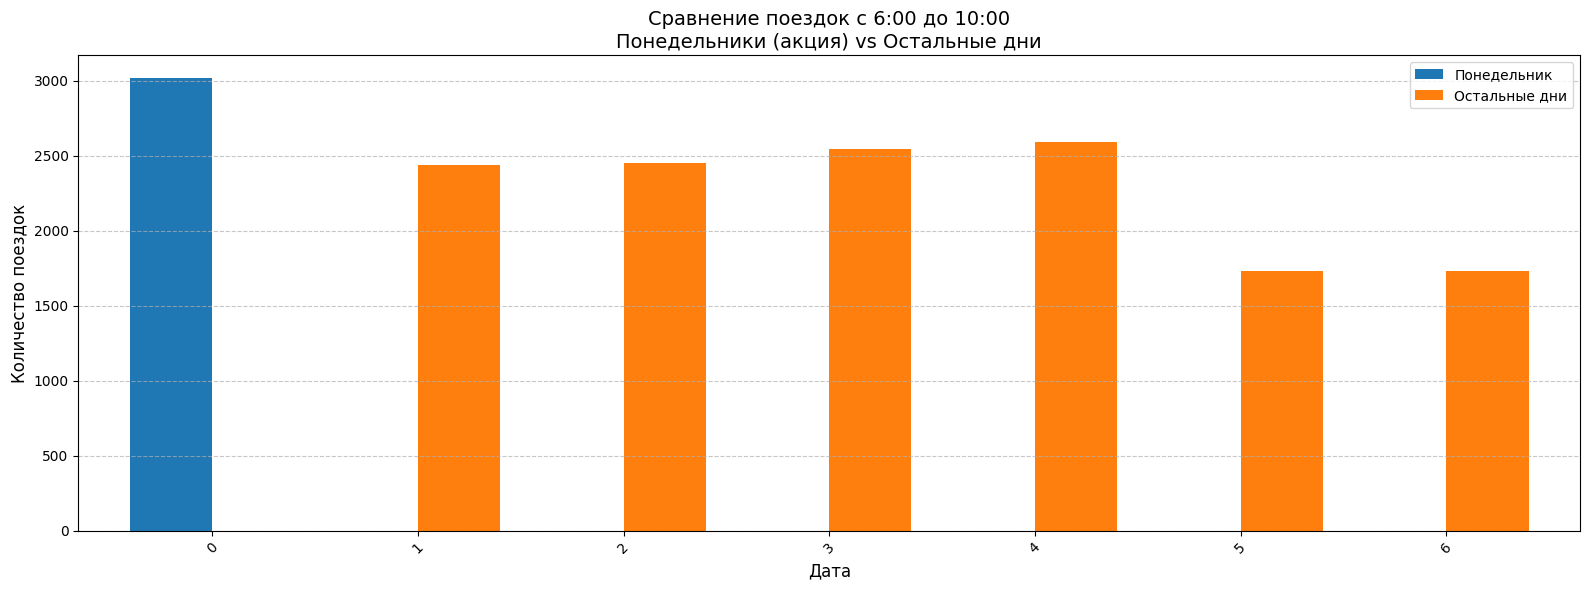

In [181]:
morning_mask = df['Start Hour'].between(6, 10)

promo_day = df[(df['Weekday'] == 0) & morning_mask]
other_days = df[(df['Weekday'] != 0) & morning_mask]

promo_day_counts = promo_day.groupby('Day of Week')['Id'].count().rename('Понедельник')
other_day_counts = other_days.groupby('Day of Week')['Id'].count().rename('Остальные дни')

comparison_df = pd.concat([promo_day_counts, other_day_counts], axis=1)

comparison_df['День акции'] = comparison_df['Понедельник'] > 0

avg_promo = comparison_df[comparison_df['День акции']]['Понедельник'].mean()
avg_other = comparison_df[~comparison_df['День акции']]['Остальные дни'].mean()

print(f"Среднее число поездок в Пн (акция): {avg_promo:.1f}")
print(f"Среднее число поездок в другие дни: {avg_other:.1f}")

plt.figure(figsize=(16, 6))
comparison_df[['Понедельник', 'Остальные дни']].plot(
    kind='bar', stacked=False, width=0.8, figsize=(16, 6), color=['#1f77b4', '#ff7f0e']
)
plt.title("Сравнение поездок с 6:00 до 10:00\nПонедельники (акция) vs Остальные дни", fontsize=14)
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Количество поездок", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

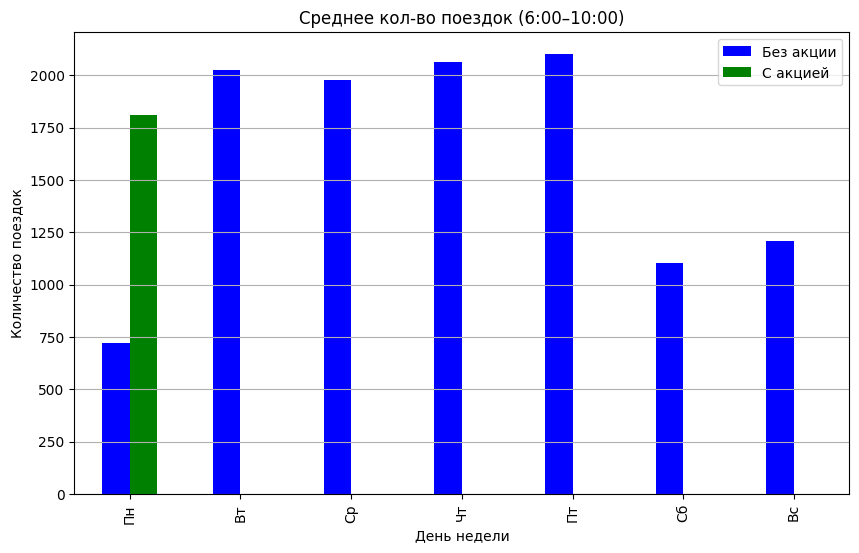

In [186]:

df['Day of Week'] = df['Start Date'].dt.dayofweek 
df['Hour'] = df['Start Date'].dt.hour

df_6_10 = df[(df['Hour'] >= 6) & (df['Hour'] < 10)]

# Разделяем данные:
# 1) Понедельники с акцией (Promo=1)
monday_promo = df_6_10[(df_6_10['Day of Week'] == 0) & (df_6_10['Promo'] == 1)]
# 2) Понедельники без акции (Promo=0)
monday_no_promo = df_6_10[(df_6_10['Day of Week'] == 0) & (df_6_10['Promo'] == 0)]
# 3) Остальные дни (вт–вс)
other_days = df_6_10[df_6_10['Day of Week'] != 0]

monday_promo_counts = monday_promo.groupby('Hour').size()
monday_no_promo_counts = monday_no_promo.groupby('Hour').size()
other_days_counts = other_days.groupby('Hour').size()

daily_avg = df_6_10.groupby(['Day of Week', 'Promo']).size().unstack()
daily_avg.index = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

daily_avg.plot(kind='bar', figsize=(10, 6), color=['blue', 'green'])
plt.title('Среднее кол-во поездок (6:00–10:00)')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.legend(['Без акции', 'С акцией'])
plt.grid(axis='y')
plt.show()


    Start District     Trip Cost        Profit  Окупаемость
0         заречный  1.639030e+06  20691.400000     0.012624
5    юго-восточный  3.186806e+06  38749.400000     0.012159
3  северо-западный  2.714836e+06  32307.466667     0.011900
1        ленинский  2.608009e+06  30078.000000     0.011533
2      октябрьский  2.176137e+06  23766.666667     0.010921
4      центральный  4.091948e+06  33280.600000     0.008133


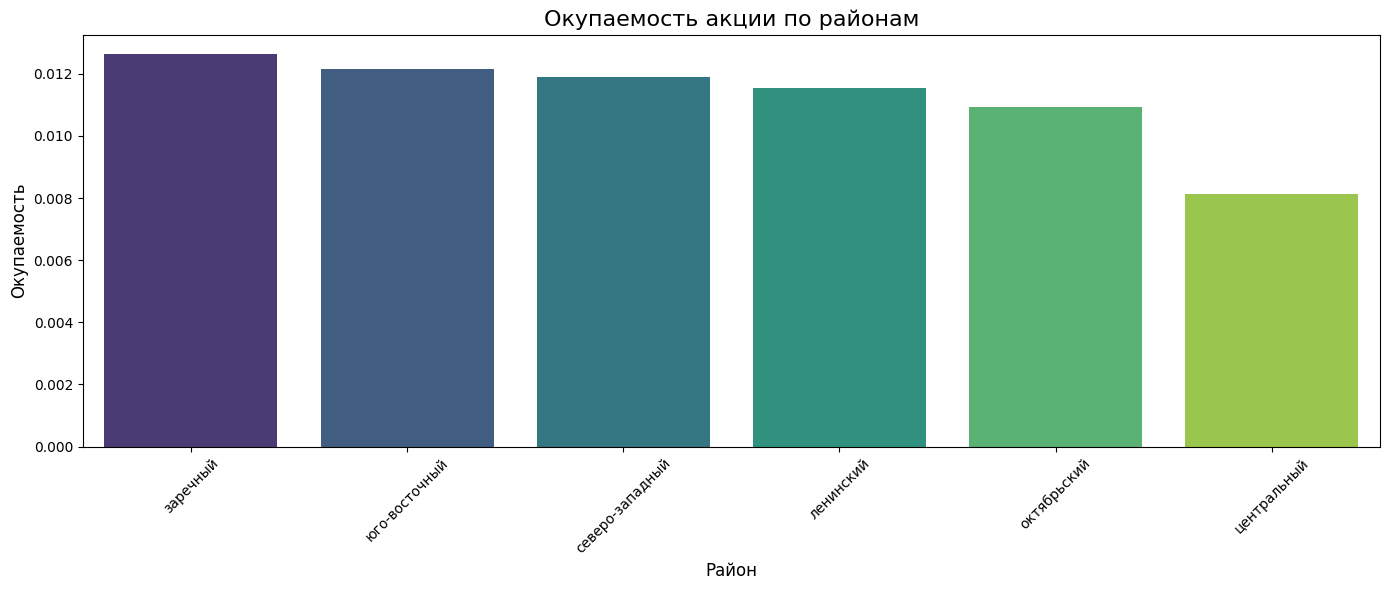

In [188]:
df['Profit'] = df['Promo'] * (df['Rate per Minute'] * df['Duration'])  # Если Promo == 1, рассчитываем прибыль от промо

profit_by_district = df.groupby('Start District').agg({
    'Trip Cost': 'sum',  # Сумма всех издержек
    'Profit': 'sum'  # Сумма прибыли от промокодов
}).reset_index()

profit_by_district['Окупаемость'] = profit_by_district['Profit'] / profit_by_district['Trip Cost']

profit_by_district = profit_by_district.sort_values(by='Окупаемость', ascending=False)

print(profit_by_district)

plt.figure(figsize=(14, 6))
sns.barplot(x='Start District', y='Окупаемость', data=profit_by_district, palette='viridis')
plt.title('Окупаемость акции по районам', fontsize=16)
plt.xlabel('Район', fontsize=12)
plt.ylabel('Окупаемость', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Районы с высокой окупаемостью: Если в некоторых районах наблюдается высокая окупаемость, это может означать, что в этих районах бесплатный старт имеет значительное влияние на прибыль, возможно, из-за высокого спроса или большего числа поездок с промокодами. Это также может свидетельствовать о том, что издержки на поездки в этих районах не столь велики, и акция действительно выгодна для бизнеса.

Районы с низкой окупаемостью: В районах с низкой окупаемостью можно сделать вывод, что либо бесплатный старт не привлекает достаточное количество клиентов, либо стоимость издержек на поездки (даже с бесплатным стартом) слишком велика для того, чтобы акция была прибыльной. Возможно, в этих районах нужно пересмотреть стратегию применения промокодов или даже исключить эту акцию.

Различия в окупаемости между районами могут указывать на важность географического положения для эффективного использования промокодов. Например, если акция работает хуже в более отдаленных или менее развитых районах, это может быть связано с меньшим спросом на поездки или меньшей плотностью поездок в этих районах.

Также стоит учесть возможность, что в некоторых районах с низким доходом людей акции с бесплатным стартом не приводят к увеличению заказов, так как спрос может быть ограничен.

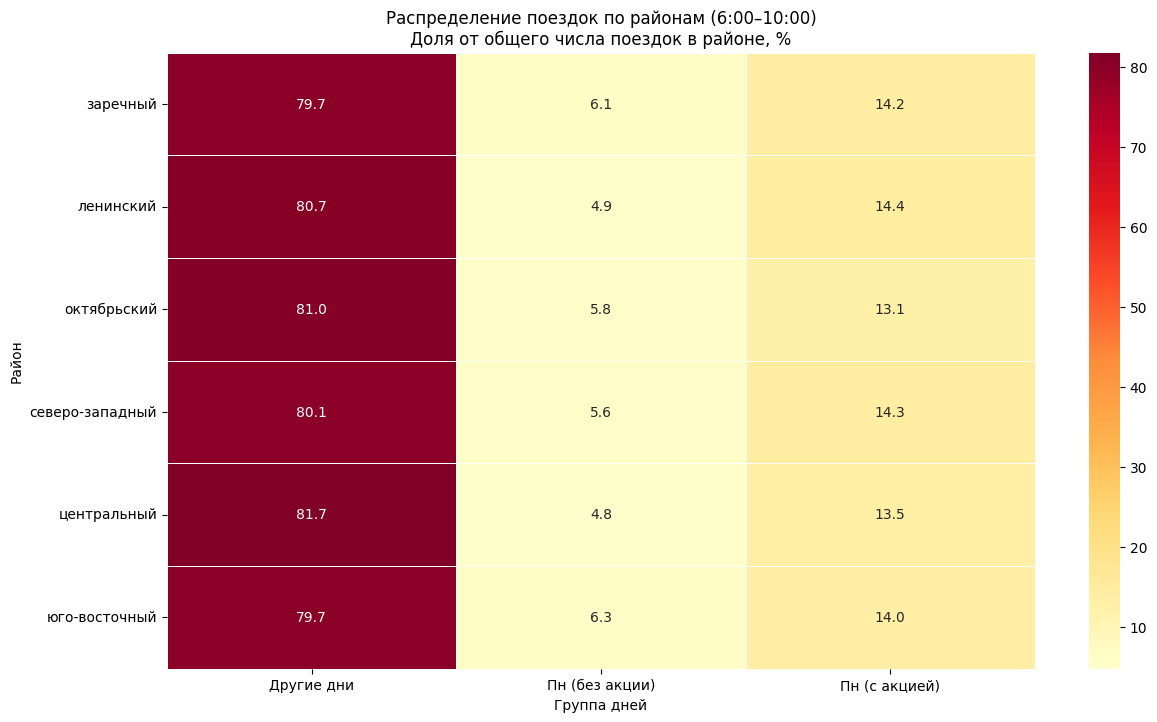

In [190]:
# Фильтрация по времени 6:00–10:00
df_6_10 = df[(df['Start Date'].dt.hour >= 6) & (df['Start Date'].dt.hour < 10)].copy()

# Создаем метки для групп
df_6_10['Day Group'] = 'Другие дни'
df_6_10.loc[(df_6_10['Day of Week'] == 0) & (df_6_10['Promo'] == 1), 'Day Group'] = 'Пн (с акцией)'
df_6_10.loc[(df_6_10['Day of Week'] == 0) & (df_6_10['Promo'] == 0), 'Day Group'] = 'Пн (без акции)'

district_counts = df_6_10.groupby(['Start District', 'Day Group']).size().unstack(fill_value=0)

district_pct = district_counts.div(district_counts.sum(axis=1), axis=0) * 100

# Визуализация
plt.figure(figsize=(14, 8))
sns.heatmap(district_pct, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Распределение поездок по районам (6:00–10:00)\nДоля от общего числа поездок в районе, %')
plt.xlabel('Группа дней')
plt.ylabel('Район')
plt.show()

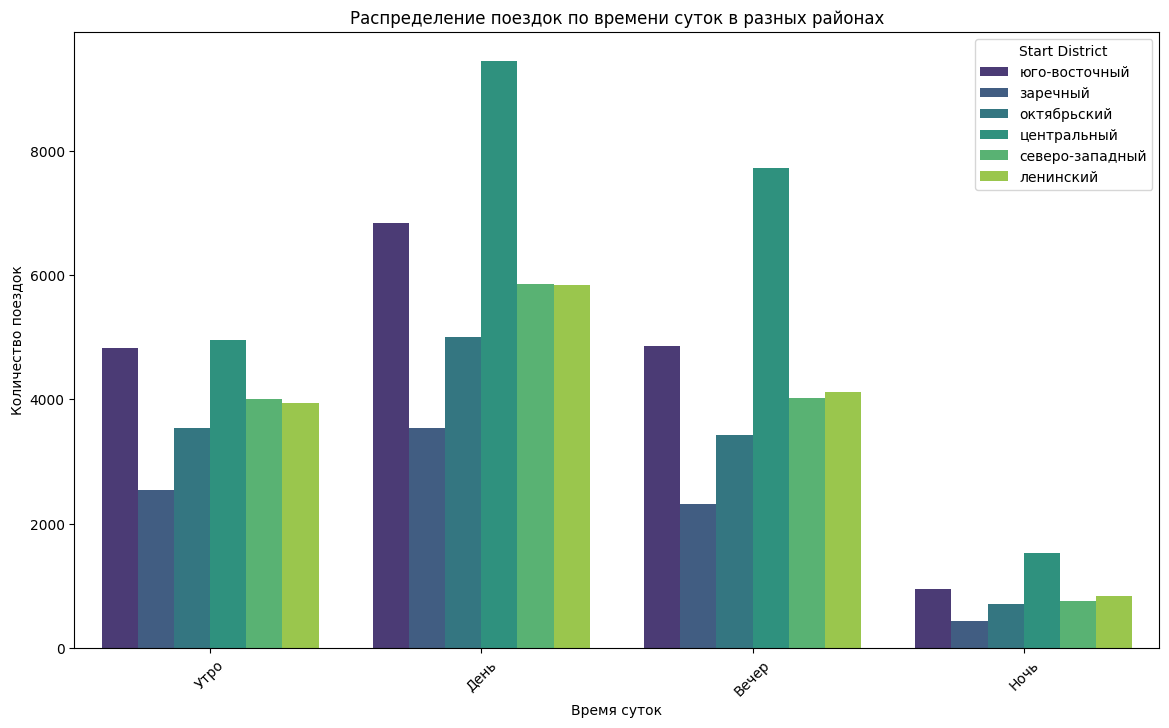

In [194]:
plt.figure(figsize=(14, 8))

sns.countplot(data=df, x='Time of Day', hue='Start District', palette='viridis')

plt.title('Распределение поездок по времени суток в разных районах')
plt.xlabel('Время суток')
plt.ylabel('Количество поездок')

plt.xticks(rotation=45)
plt.show()

In [196]:
start_cost = 30
df1 = df.copy()
df1['Adjusted Trip Cost'] = df1.apply(lambda row: row['Trip Cost'] - start_cost if row['Promo'] == 1 else row['Trip Cost'], axis=1)

promo_trips = df1[df1['Promo'] == 1]
non_promo_trips = df1[df1['Promo'] == 0]

total_income_with_promo = promo_trips['Adjusted Trip Cost'].sum()
total_income_without_promo = non_promo_trips['Trip Cost'].sum()

promo_cost = promo_trips.shape[0] * start_cost

print(f"Общий доход от поездок с промо: {total_income_with_promo:.2f} рублей")
print(f"Общий доход от поездок без промо: {total_income_without_promo:.2f} рублей")
print(f"Затраты на проведение акции (стоимость старта): {promo_cost:.2f} рублей")

profit_or_loss = total_income_with_promo + total_income_without_promo - promo_cost
if profit_or_loss >= 0:
    print(f"Акция окупается. Прибыль: {profit_or_loss:.2f} рублей")
else:
    print(f"Акция не окупается. Убыток: {profit_or_loss:.2f} рублей")


Общий доход от поездок с промо: 124603.53 рублей
Общий доход от поездок без промо: 16237891.47 рублей
Затраты на проведение акции (стоимость старта): 54270.00 рублей
Акция окупается. Прибыль: 16308225.00 рублей


- Общий доход от поездок с промо: 124603.53 рублей- 
Общий доход от поездок без промо: 16237891.47 рублей- 
Затраты на проведение акции (стоимость старта): 54270.00 рубл
- й
Акция окупается. Прибыль: 16308225.00 рублей

In [ ]:
# Преобразуем дату и создадим колонку только с датой
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['Date'] = df['Start Date'].dt.date

# Количество отъездов из каждой точки по датам
out_df = df.groupby(['Date', 'Start Location']).size().reset_index(name='outflow')

# Количество приездов в каждую точку по датам
in_df = df.groupby(['Date', 'End Location']).size().reset_index(name='inflow')

# Переименуем колонки для объединения
out_df.rename(columns={'Start Location': 'Location'}, inplace=True)
in_df.rename(columns={'End Location': 'Location'}, inplace=True)

# Объединяем и считаем net_change
point_net = pd.merge(in_df, out_df, on=['Date', 'Location'], how='outer').fillna(0)
point_net['net_change'] = point_net['inflow'] - point_net['outflow']

# Сортировка и накопление
point_net.sort_values(['Location', 'Date'], inplace=True)
point_net['cumsum'] = point_net.groupby('Location')['net_change'].cumsum()


In [ ]:
required_scooters = point_net.groupby('Location')['cumsum'].max().reset_index()
required_scooters.rename(columns={'cumsum': 'Required Scooters'}, inplace=True)
required_scooters = required_scooters.sort_values(by='Required Scooters', ascending=False)
print(required_scooters)


# 2.1 Определить топ-3 точки с самым высоким

In [ ]:
from tqdm import tqdm
df['DateOnly'] = df['Datetime'].dt.date

# Теперь можно сгруппировать по дате
gbd = df.groupby('DateOnly')
list_data = []
for date, group in gbd:
    list_data.append([date, group])


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
average_samokat = []
for i in list_data:
    da = [i[0]]
    datafr = i[1]
    first = datafr['Start Location'].value_counts().to_frame()
    second = datafr['End Location'].value_counts().to_frame()
    second.columns = ['leave']
    first.columns = ['inter']
    second.index.name = 'Start Location'
    fin = first.merge(second, on='Start Location')
    fin['turn_per_day'] = fin['inter'] + fin['leave']
    da.append(fin.sort_values(by='turn_per_day', ascending=False))
    average_samokat.append(da)

def union_all_data(x):
    h = x[0]
    for k in range(len(x)):
        h = pd.concat([h, x[k]])
    return h

all_trafic = union_all_data(list(map(lambda x: x[1], average_samokat)))
all_trafic = all_trafic.groupby('Start Location')[['inter', 'leave', 'turn_per_day']].agg('sum').sort_values(by='turn_per_day', ascending=False)

In [ ]:
all_trafic

In [ ]:
import matplotlib.pyplot as plt
# Строим график
plt.figure(figsize=(15, 10))
bars = plt.bar(all_trafic.index, all_trafic['turn_per_day'], color='lightcoral')

# Подписи на столбиках
for bar in bars:
    height = bar.get_height()  # Получаем высоту столбика (это количество поездок для конкретной локации)
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{int(height)}',
             ha='center', va='bottom', fontsize=9)  # Размещаем текст в центре столбика

# Оформление
plt.title('Топ-3 точки с самым высоким трафиком (поездки)')
plt.xlabel('Точка (улица)')
plt.ylabel('Количество поездок')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Отображение графика
plt.show()


**Стоит ли закрывать некоторые точки?**

In [ ]:
weekdays = {}

# tqdm добавляет прогресс-бар к итерации
for i in tqdm(list_data, desc="Обработка данных по дням недели"):
    f = dict(tuple(i[1].groupby('weekday')))
    ind = list(set(f.keys()))
    for k in ind:
        h = f[k]
        h = h[h['Start Season'] == 'Весна']
        if isinstance(weekdays.get(k, 0), int):
            weekdays[k] = h
        else:
            weekdays[k] = pd.concat([weekdays[k], h])

average_samokat_to_weekdays = []
for i in weekdays.keys():
    da = [i]
    datafr = weekdays[i]
    first = datafr['Start Location'].value_counts().to_frame()
    second = datafr['End Location'].value_counts().to_frame()
    third = datafr.groupby('Start Location')['Trip Cost'].agg('sum').to_frame()
    second.columns = ['leave']
    first.columns = ['inter']
    second.index.name = 'Start Location'
    fin = third.merge(first.merge(second, on='Start Location'), on='Start Location')
    fin['turn_per_day'] = fin['inter'] + fin['leave']
    da.append(fin.sort_values(by='turn_per_day', ascending=False))
    average_samokat_to_weekdays.append(da)

dat = average_samokat_to_weekdays[0][1]
for i in average_samokat_to_weekdays[1:]:
    dat += i[1]

In [ ]:
dat = dat.sort_values(by='Trip Cost', ascending=False)
dat

In [ ]:
popular = dat.index[:10] # Топ-10 самых популярных улиц

In [ ]:
un_popular = dat.index[-10:] # Топ-10 самых непопулярных улиц

In [ ]:
popular

In [ ]:
un_popular

In [ ]:
sum(dat['Trip Cost'][:])

In [ ]:
sum(dat['Trip Cost'][:19])

In [ ]:
sum(dat['Trip Cost'][-19:])

In [ ]:
(sum(dat['Trip Cost'][:19]) / sum(dat['Trip Cost'][:])) * 100

In [ ]:
(sum(dat['Trip Cost'][-19:]) / sum(dat['Trip Cost'][:])) * 100

In [ ]:
def get_arrival_sources_summary(df):
    # Все уникальные конечные локации
    end_locations = df['End Location'].unique()

    summary_dict = {}

    for end_loc in end_locations:
        # Фильтруем только поездки, заканчивающиеся в этой точке
        arrivals = df[df['End Location'] == end_loc]

        # Группируем по Start Location и считаем поездки
        grouped = arrivals.groupby('Start Location').size().reset_index(name='trips')

        # Считаем долю от общего количества
        total = grouped['trips'].sum()
        grouped['percent'] = (grouped['trips'] / total * 100).round(1)

        # Сортируем по убыванию
        grouped = grouped.sort_values(by='trips', ascending=False).reset_index(drop=True)

        summary_dict[end_loc] = grouped

    return summary_dict

arrival_summary_by_end_location = get_arrival_sources_summary(merged_df)


In [ ]:
popular

In [ ]:
grouped_streets_by_district = merged_df.groupby('Start District')['Start Location'].unique().to_frame()
grouped_streets_by_district = pd.DataFrame(grouped_streets_by_district)
grouped_streets_by_district['1'] = grouped_streets_by_district['Start Location'].apply(len)
reversed_dict = {}
for k, v in grouped_streets_by_district.drop(columns=['1']).to_dict()['Start Location'].items():
    for v1 in v:
        reversed_dict[v1] = k

In [ ]:
for i in popular:
    print(i)
    n = arrival_summary_by_end_location[i]
    n['district'] = n['Start Location'].apply(lambda x: reversed_dict[x])
    print(n.head(10))

In [ ]:
for i in un_popular:
    print(i)
    n = arrival_summary_by_end_location[i]
    n['district'] = n['Start Location'].apply(lambda x: reversed_dict[x])
    print(n.head(10))

In [ ]:
for j in popular:
    print(reversed_dict[j])

In [ ]:
for j in un_popular:
    print(reversed_dict[j])

**Вывод**: не стоит закрывать не одну точку, так как каждая делает свой достаточный вклад в общую сумму выручки.

**Самые популярные направления перемещения**

In [ ]:
# Считаем количество поездок для каждой пары (маршрута)
route_counts = merged_df.groupby(['Start Location', 'End Location']).size().reset_index(name='trips')

# Сортируем по убыванию количества
most_popular_route = route_counts.sort_values(by='trips', ascending=False)

# Выводим результат
start = most_popular_route['Start Location']
end = most_popular_route['End Location']
count = most_popular_route['trips']

most_popular_route.head(10)

**Есть ли необходимость перераспределять самокаты в конце дня?**

In [ ]:
departures = merged_df.groupby('Start Location').size().reset_index(name='departures')
arrivals = merged_df.groupby('End Location').size().reset_index(name='arrivals')

# Объединяем данные
balance = pd.merge(arrivals, departures,
                   left_on='End Location', right_on='Start Location',
                   how='outer')

# Заполняем пропуски нулями (если в локации были только приезды или только уезды)
balance['End Location'] = balance['End Location'].combine_first(balance['Start Location'])
balance = balance.drop(columns=['Start Location'])
balance = balance.rename(columns={'End Location': 'Location'})
balance['arrivals'] = balance['arrivals'].fillna(0)
balance['departures'] = balance['departures'].fillna(0)

# Считаем чистый приток
balance['net_flow'] = balance['arrivals'] - balance['departures']

# Сортировка по притоку
balance = balance.sort_values(by='net_flow', ascending=False)

# Визуализация
plt.figure(figsize=(16, 6))
sns.barplot(data=balance, x='Location', y='net_flow', palette='coolwarm')
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45)
plt.title('Чистый приток самокатов по локациям за день (приехало - уехало)')
plt.ylabel('Чистый приток')
plt.xlabel('Локация')
plt.tight_layout()
plt.show()


In [ ]:
balance[balance['net_flow'] >= 0]['net_flow'].sum()

In [ ]:
balance['total_traffic'] = balance['arrivals'] + balance['departures']

# Шаг 2: Посчитаем долю трафика каждой станции
balance['traffic_share'] = balance['total_traffic'] / balance['total_traffic'].sum()

# Шаг 3: Задаем общее количество самокатов (например, 1000)
total_scooters = balance[balance['net_flow'] >= 0]['net_flow'].sum()
balance['target_scooters'] = (balance['traffic_share'] * total_scooters).round().astype(int)

# Шаг 4: Подгоняем так, чтобы сумма была ровно равна total_scooters
diff = total_scooters - balance['target_scooters'].sum()
if diff != 0:
    # Добавляем или убавляем по одной штуке с самых трафиковых точек
    adjust_indices = balance['total_traffic'].sort_values(ascending=(diff < 0)).index[:abs(diff)]
    balance.loc[adjust_indices, 'target_scooters'] += np.sign(diff)

# Результат
final_distribution = balance[['Location', 'target_scooters']].sort_values(by='target_scooters', ascending=False)

# Визуализация
plt.figure(figsize=(16, 6))
sns.barplot(data=final_distribution, x='Location', y='target_scooters', palette='viridis')
plt.xticks(rotation=45)
plt.title('Рекомендуемое распределение самокатов по локациям')
plt.ylabel('Количество самокатов')
plt.xlabel('Локация')
plt.tight_layout()
plt.show()


In [ ]:
final_distribution['target_scooters'].sum() == balance[balance['net_flow'] >= 0]['net_flow'].sum()

# 2.2. Изучить накопительное поведение разницы в трафике в каждой точке

Группировка данных по каждой точке, считаем отток и приток по каждому времени.

In [ ]:
merged_df['weekday'] = merged_df['Start Date'].dt.weekday
merged_df['Start Month'] = merged_df['Start Date'].apply(lambda x: x.month)
merged_df['End Month'] = merged_df['End Date'].dt.month
seasons = {
    12: 'Зима', 1: 'Зима', 2: 'Зима',
    3: 'Весна', 4: 'Весна', 5: 'Весна',
    6: 'Лето', 7: 'Лето', 8: 'Лето',
    9: 'Осень', 10: 'Осень', 11: 'Осень'
}
merged_df['Start Season'] = merged_df['Start Month'].map(seasons)
merged_df['End Season'] = merged_df['End Month'].map(seasons)
merged_df['Time start'] = merged_df['Start Date'].dt.time
merged_df['Time end'] = merged_df['End Date'].dt.time
merged_df['Trip Duration'] = (merged_df['End Date'] - merged_df['Start Date']).dt.total_seconds() / 60
def get_rate(weekday, hour):
    if weekday < 5:  # Пн–Пт
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 5
        elif 16 <= hour < 22:
            return 6
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 5
    else:  # Сб–Вс
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 6
        elif 16 <= hour < 22:
            return 7
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 6

merged_df['Start Hour'] = merged_df['Start Date'].dt.hour
merged_df['Rate per Minute'] = merged_df.apply(lambda row: get_rate(row['weekday'], row['Start Hour']), axis=1)
merged_df['Trip Cost'] = merged_df['Trip Duration'] * merged_df['Rate per Minute']

In [ ]:
import pandas as pd

# Преобразуем данные в нужный формат
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])
df['Date'] = df['Start Date'].dt.date  # Извлекаем только дату

# Отток и приток по точкам (по каждой локации)
outflow = df.groupby(['Date', 'Start Location']).size().reset_index(name='outflow')
inflow = df.groupby(['Date', 'End Location']).size().reset_index(name='inflow')

# Переименуем для объединения данных
outflow.rename(columns={'Start Location': 'Location'}, inplace=True)
inflow.rename(columns={'End Location': 'Location'}, inplace=True)

# Объединяем отток и приток
net_flow = pd.merge(inflow, outflow, on=['Date', 'Location'], how='outer').fillna(0)

# Рассчитываем разницу в трафике
net_flow['net_change'] = net_flow['inflow'] - net_flow['outflow']

# Накопительная сумма для каждой точки по дням
net_flow.sort_values(['Location', 'Date'], inplace=True)
net_flow['cumsum'] = net_flow.groupby(['Location'])['net_change'].cumsum()

# Просмотр результатов
print(net_flow.head())


**Построение графика накопительной разницы по точкам**

In [ ]:
import matplotlib.pyplot as plt

# Группируем по точке и строим графики для каждой точки
locations = net_flow['Location'].unique()

plt.figure(figsize=(16, 8))

for i, loc in enumerate(locations[:10]):  # Ограничим вывод 10 точками для наглядности
    temp = net_flow[net_flow['Location'] == loc]
    plt.plot(temp['Date'], temp['cumsum'], label=loc)

plt.title('Накопительное изменение трафика по точкам (Cumsum)')
plt.xlabel('Дата')
plt.ylabel('Накопительное изменение трафика')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Задача 2: Определить необходимое количество самокатов в каждой точке и районе для удовлетворения спроса в полном объеме**

In [ ]:
# Максимальное количество самокатов по каждой точке
required_scooters = net_flow.groupby('Location')['cumsum'].max().reset_index()
required_scooters.rename(columns={'cumsum': 'Required Scooters'}, inplace=True)

# Просмотр результатов
required_scooters.sort_values(by='Required Scooters').head()

**Определение необходимого количества самокатов по районам**

In [ ]:
# Добавляем информацию о районах
location_district_map = df[['Start Location', 'Start District']].drop_duplicates()
required_scooters = required_scooters.merge(location_district_map, left_on='Location', right_on='Start Location', how='left')

# Рассчитываем необходимое количество самокатов по районам
district_scooters = required_scooters.groupby('Start District')['Required Scooters'].sum().reset_index()

# Просмотр результатов
print(district_scooters.head())


**Построение графиков для самокатов по точкам и районам.**




In [ ]:
import matplotlib.pyplot as plt

# Отбираем топ-30 точек с наибольшим спросом
top_n = 30
top_scooters = required_scooters.sort_values('Required Scooters', ascending=False).head(top_n)

# Создаём график
plt.figure(figsize=(16, 7))
bars = plt.bar(top_scooters['Location'], top_scooters['Required Scooters'], color='skyblue')

# Добавляем подписи на столбиках
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{int(height)}',
             ha='center', va='bottom', fontsize=8)

# Добавляем пояснение
plt.text(0, top_scooters['Required Scooters'].max() + 3,
         f'',
         fontsize=11, ha='left', va='bottom', color='green')

# Оформление графика
plt.title(f'Топ-{top_n} точек по необходимому количеству самокатов', fontsize=15)
plt.xlabel('Точка (улица)', fontsize=12)
plt.ylabel('Необходимое количество самокатов', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


**По районам -график показывает, сколько самокатов требуется для покрытия ежедневного спроса в различных районах города. Высокие столбцы на графике указывают на районы с более интенсивным спросом на самокаты. В нашем случае - центральный**

In [ ]:
plt.figure(figsize=(10, 5))
bars = plt.bar(district_scooters['Start District'], district_scooters['Adjusted Scooters'], color='teal')

plt.title('Скорректированное количество самокатов по районам (учёт приоритетов)')
plt.xlabel('Район')
plt.ylabel('Рекомендуемое количество самокатов')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# 3.Исследовать корреляцию между параметрами погодных условий

# Гипотезы - 6 шт

* Нулевая - Влияет ли солнечность погоды на длину поездки?
* Альернатива - Солнечность погоды не влияет на длину поездки.

In [ ]:
df[['Sunshine Duration', 'Distance']]

In [ ]:
from scipy.stats import spearmanr

filtered = df[['Distance', 'Sunshine Duration']].dropna()
correlation, p_value = spearmanr(filtered['Sunshine Duration'], filtered['Distance'])

print(f"Корреляция: {correlation}")
print(f"p-значение: {p_value}")


Нулевая гипотиза опровергнута, значит можем утверждать, что **солнечность погоды не влияет на длину поездки**

* Нулевая - Влияет ли день недели на длину поездки?
* Альернатива - День недели не влияет на длину поездки.

In [ ]:
filtered = df[['Distance', 'weekday']].dropna()
correlation, p_value = spearmanr(filtered['weekday'], filtered['Distance'])

print(f"Корреляция: {correlation}")
print(f"p-значение: {p_value}")

Вывод: да, **есть сильная зависимость между днем недели и длиной поездки**

* Нулевая - Падает ли спрос на самокаты в середине недели и происходит из-за постоянного ухудшения погоды именно в эти дни
* Альернатива - спрос не падает в середине недели из-за постоянного ухудшения погоды

In [ ]:
# Вывести названия всех столбцов
print(df.columns)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('weather.csv')

# Преобразуем дату и извлечем день недели
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')
df['Weekday'] = df['Datetime'].dt.weekday  # 0 = понедельник, 6 = воскресенье

# Проверим, есть ли пропущенные значения в 'Weekday' и заменим их (если есть)
df['Weekday'] = df['Weekday'].fillna(-1).astype(int)  # -1 на случай NaN значений

# Преобразуем погодные столбцы в числовой формат
weather_columns = ['Temperature', 'Precipitation Total', 'Cloud Cover Total', 'Wind Speed']
for col in weather_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Заполним пропущенные значения средними
df[weather_columns] = df[weather_columns].fillna(df[weather_columns].mean())

# Группировка: средняя погода по дням недели
agg_df = df.groupby('Weekday').agg({
    'Temperature': 'mean',
    'Precipitation Total': 'mean',
    'Cloud Cover Total': 'mean',
    'Wind Speed': 'mean'
}).reset_index()

# Названия дней недели
day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
agg_df['Weekday Name'] = agg_df['Weekday'].map(lambda x: day_names[int(x)] if x >= 0 and x < len(day_names) else 'Невалидный день')

# Визуализация: температура и осадки по дням недели
plt.figure(figsize=(12, 6))
plt.plot(agg_df['Weekday Name'], agg_df['Temperature'], label='Температура (°C)', marker='o')
plt.plot(agg_df['Weekday Name'], agg_df['Precipitation Total'], label='Осадки (мм)', marker='s')
plt.title('Температура и осадки по дням недели')
plt.xlabel('День недели')
plt.grid(True)
plt.legend()
plt.show()

# Визуализация: облачность и скорость ветра по дням недели
plt.figure(figsize=(12, 6))
plt.plot(agg_df['Weekday Name'], agg_df['Cloud Cover Total'], label='Облачность (%)', marker='o')
plt.plot(agg_df['Weekday Name'], agg_df['Wind Speed'], label='Скорость ветра (м/с)', marker='s')
plt.title('Облачность и скорость ветра по дням недели')
plt.xlabel('День недели')
plt.grid(True)
plt.legend()
plt.show()

# Корреляция между погодой
corr = agg_df[['Temperature', 'Precipitation Total', 'Cloud Cover Total', 'Wind Speed']].corr()
print("Корреляция между погодными условиями:\n")
print(corr)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('rides.csv')  # замените на имя вашего файла

# Преобразуем дату начала в datetime, если необходимо
df['Start Date'] = pd.to_datetime(df['Start Date'], errors='coerce')

# Если нет числового дня недели — добавим его
if 'Weekday' not in df.columns:
    df['Weekday'] = df['Start Date'].dt.weekday  # 0 = Monday, 6 = Sunday

# Названия дней недели для красивой подписи
day_map = {
    0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт',
    4: 'Пт', 5: 'Сб', 6: 'Вс'
}
df['Weekday Name'] = df['Weekday'].map(day_map)

# Группируем: считаем количество поездок на каждый день недели
trip_counts = df['Weekday Name'].value_counts().reindex(['Пн','Вт','Ср','Чт','Пт','Сб','Вс'])

# Визуализация
plt.figure(figsize=(10, 6))
trip_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Спрос на самокаты по дням недели', fontsize=14)
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Загрузка данных
rides = pd.read_csv('rides.csv')
weather = pd.read_csv('weather.csv')

# Преобразуем даты
rides['Start Date'] = pd.to_datetime(rides['Start Date'], errors='coerce')
weather['Datetime'] = pd.to_datetime(weather['Datetime'], errors='coerce')

# Добавим колонку "Date" и "Weekday"
rides['Date'] = rides['Start Date'].dt.date
rides['Weekday'] = rides['Start Date'].dt.weekday  # 0=Пн
weather['Date'] = weather['Datetime'].dt.date
weather['Weekday'] = weather['Datetime'].dt.weekday

# Числовое преобразование погодных столбцов
weather_cols = ['Temperature', 'Precipitation Total', 'Cloud Cover Total', 'Wind Speed']
for col in weather_cols:
    weather[col] = pd.to_numeric(weather[col], errors='coerce')

# Группировка: усреднённая погода по дню
weather_daily = weather.groupby(['Date', 'Weekday'])[weather_cols].mean().reset_index()

# Количество поездок по дате
rides_daily = rides.groupby(['Date', 'Weekday']).size().reset_index(name='Ride Count')

# Объединение данных
merged = pd.merge(rides_daily, weather_daily, on=['Date', 'Weekday'], how='inner')

# Добавим названия дней недели
day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
merged['Weekday Name'] = merged['Weekday'].map(lambda x: day_names[x])

# --------------------
# 📊 Визуализация спроса
# --------------------
plt.figure(figsize=(10, 5))
merged.groupby('Weekday Name')['Ride Count'].mean().reindex(day_names).plot(kind='bar', color='skyblue')
plt.title("Средний спрос на самокаты по дням недели")
plt.xlabel("День недели")
plt.ylabel("Среднее количество поездок")
plt.grid(axis='y')
plt.show()

# --------------------
# 🧪 Статистическая проверка гипотезы (t-test)
# --------------------
# Группы: середина недели (Вт, Ср, Чт) против остального времени
midweek = merged[merged['Weekday'].isin([1, 2, 3])]['Ride Count']
non_midweek = merged[~merged['Weekday'].isin([1, 2, 3])]['Ride Count']

t_stat, p_value = ttest_ind(midweek, non_midweek, equal_var=False)

print("Результаты t-теста:")
print(f"t-статистика: {t_stat:.3f}")
print(f"p-значение: {p_value:.4f}")

# --------------------
# 📈 Корреляция погоды и спроса
# --------------------
corr = merged[['Ride Count', 'Temperature', 'Precipitation Total', 'Cloud Cover Total', 'Wind Speed']].corr()
print("\nКорреляция между погодными условиями и спросом на самокаты:")
print(corr['Ride Count'].sort_values(ascending=False))


Температура и осадки имеют положительную корреляцию (0.459). Это значит, что при повышении температуры количество поездок увеличивается, а при увеличении осадков — уменьшается.

Облачность и осадки также имеют отрицательную корреляцию с количеством поездок. То есть, когда облачность и осадки увеличиваются, количество поездок уменьшается.

Скорость ветра имеет слабую отрицательную корреляцию с количеством поездок (-0.197), что также может указывать на то, что при сильном ветре спрос на самокаты несколько снижается.

**Вывод**: спрос падает из-за ухудшения погоды в определенные дни недели

* Нулевая - все поездки на самокатах происходят в пределах одного района в пределах 1 района

* Альтернатива - Поездки на самокатах происходят не только в пределах одного района, и существует статистически значимая разница в распределении поездок между различными районами."

In [ ]:
start_counts = df['Start District'].value_counts()
end_counts = df['End District'].value_counts()

district_counts = (start_counts + end_counts).fillna(0)

# Определяем центр и окраины
threshold_center = district_counts.quantile(0.75)  # Верхние 25% - центр
threshold_outskirts = district_counts.quantile(0.25)  # Нижние 25% - окраины

districts = pd.DataFrame({'District': district_counts.index, 'Trips': district_counts.values})
districts['Category'] = 'Middle'
districts.loc[districts['Trips'] >= threshold_center, 'Category'] = 'Center'
districts.loc[districts['Trips'] <= threshold_outskirts, 'Category'] = 'Outskirts'
print(districts)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки визуализации
plt.figure(figsize=(14, 6))
sns.barplot(data=districts.sort_values('Trips', ascending=False), x='District', y='Trips', hue='Category', dodge=False)
plt.title('Количество поездок по районам')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Добавляем колонку: поездка внутри района или нет
df['Same District'] = df['Start District'] == df['End District']

# 2. Считаем общее количество поездок по каждому району
district_trip_counts = df.groupby('Start District').size().sort_values(ascending=False)

# 3. Рассчитываем долю поездок внутри района и между районами по каждому району
district_movement = df.groupby('Start District')['Same District'].value_counts(normalize=True).unstack().fillna(0)

# 4. Переименуем колонки для удобства
district_movement.columns = ['Between Districts', 'Within Same District']

# 5. Сортируем районы по количеству поездок
district_movement = district_movement.loc[district_trip_counts.index]

# 6. Построение графика
plt.figure(figsize=(14, 7))
district_movement[['Within Same District', 'Between Districts']].plot(kind='bar', stacked=True, color=['mediumseagreen', 'tomato'], figsize=(14,7))

# 7. Настройки графика
plt.title('Зависимость: Поездки внутри района vs между районами (по популярности районов)', fontsize=16)
plt.ylabel('Доля поездок', fontsize=12)
plt.xlabel('Районы', fontsize=12)
plt.xticks(rotation=90)
plt.legend(title='Тип поездки', labels=['Внутри района', 'Между районами'])
plt.tight_layout()
plt.show()

Альтернативная гипотеза подтверждается, потому что:
Межрайонные поездки — это устойчивая часть всех поездок.
Для разных районов их доля значительно варьируется (в одних районах больше поездок внутри, в других — наоборот).

Вывод: Поездки на самокатах происходят не только в пределах одного района,